In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import mne
import numpy as np
from tqdm import tqdm
import re
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from multiprocessing import Pool
import warnings

warnings.filterwarnings("ignore")

os.chdir('../..')

# Load Morlet PSDs

In [2]:
#loaded = np.load('./Generated/Spectrums/psds_array_morlet.npz')
loaded = np.load('C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Generated/Spectrums/psds_array_morlet.npz')

results_arr = []

i = 0
while f'psd_{i}' in loaded:
    psd = loaded[f'psd_{i}']
    s_id = int(loaded[f'subject_id_{i}'])
    t_id = int(loaded[f'trial_id_{i}'])
    gender = str(loaded[f'gender_{i}'])
    handiness = str(loaded[f'handiness_{i}'])
    age = int(loaded[f'age_{i}'])
    
    results_arr.append([psd, s_id, t_id, gender, handiness, age])
    i += 1

psd, s_id, t_id, gender, handiness, age = results_arr[0]
psd.shape

(63, 80)

In [3]:
# Parse into two lists will be used furthere
psds_array = [item[0] for item in results_arr]
psds_array = np.array(psds_array)                            # Convert list of PSDs to a numpy array
psds_array = psds_array.reshape((psds_array.shape[0], -1))   # Vectorize 

metadata = [item[1:] for item in results_arr]

psds_array.shape

(31, 5040)

### Normalize Each Spectrum
Why not to normalize by channels? - Because the chennel relevance to each other may be lost. For instance some chanels may have higher power for particular freq band.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
psds_array = scaler.fit_transform(psds_array)

# Dimentionality Reduction
Every method produces `reduced_data` variable wich is `27xN` shape, where `N` is the reduction dimentionality.

### PCA

In [5]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 18
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 18)

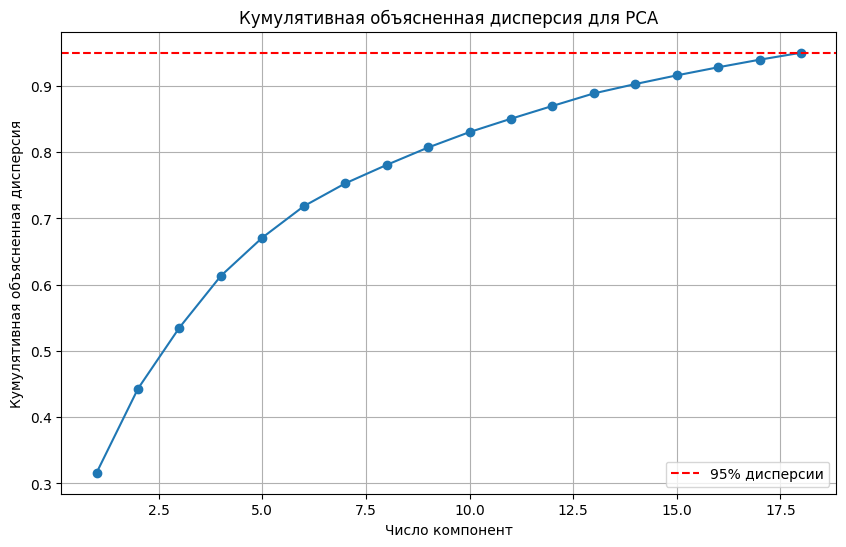

In [6]:
# Анализ объясненной дисперсии
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Визуализация кумулятивной дисперсии
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число компонент')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('Кумулятивная объясненная дисперсия для PCA')
plt.grid(True)
plt.legend()
plt.show()

# Best 17 dim

# Clusterization
* `KNN` - 
* `DBSCAN` - 
* `HDBSCAN` -
* `GMM` -
* `Spectral Clustering` -
* `Agglomerative` - 

### KNN
Best for `PCA` k=2 (Но оно всеравно меньше 0.5, а значит не столь надежно)

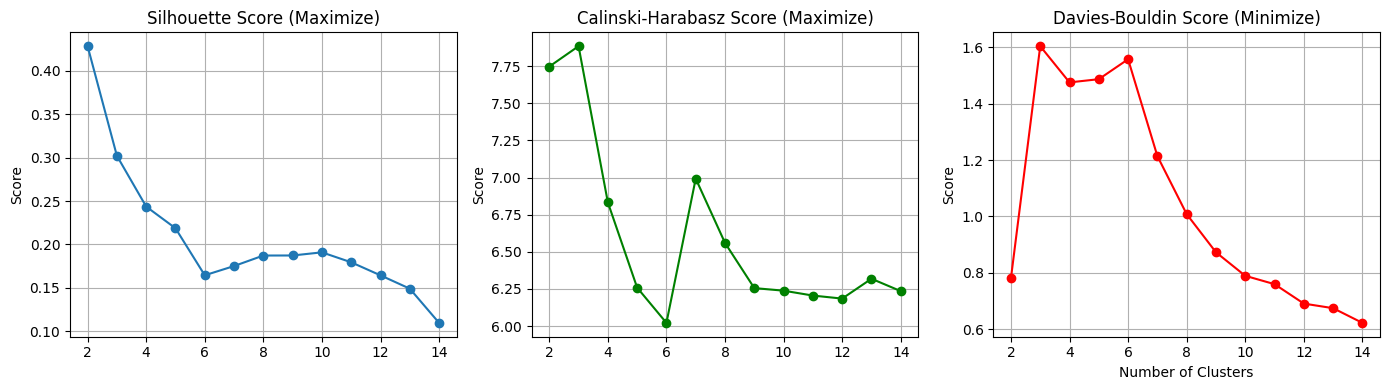

In [7]:
from sklearn.cluster import KMeans

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [8]:
k = 2  # предположительное количество кластеров
kmeans = KMeans(n_clusters=k, random_state=42)
labels_knn = kmeans.fit_predict(reduced_data)

### DBSCAN
Best for `PCA` - Излом на 90

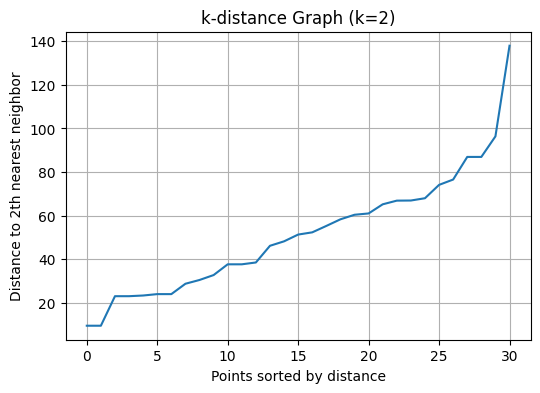

In [9]:
from sklearn.neighbors import NearestNeighbors

min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(reduced_data)
distances, indices = neighbors_fit.kneighbors(reduced_data)

# берем расстояние до k-го соседа (по столбцу)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance Graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.grid(True)
plt.show()



In [10]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering in high-dimensional space
dbscan = DBSCAN(eps=90, min_samples=2)  # eps можно варьировать
labels_dbscan = dbscan.fit_predict(reduced_data)

### HDBSCAN

In [11]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
labels_hdbscan = clusterer.fit_predict(reduced_data)

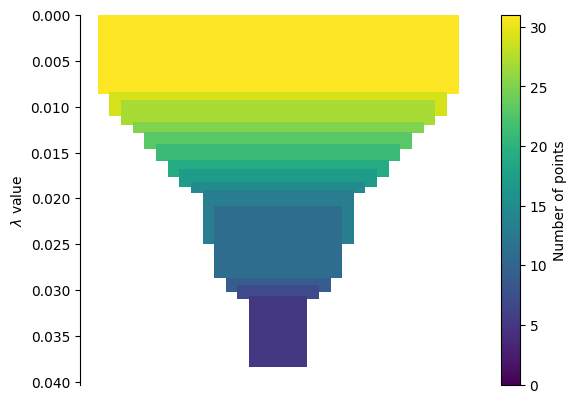

In [12]:
clusterer.condensed_tree_.plot()
pass

### GMM
`n_components`: количество гауссовых компонентов. Подбирается через BIC:

BIC (Bayesian Information Criterion) — это метрика, которая балансирует:

качество подгонки модели (log-likelihood — чем выше, тем лучше)

сложность модели (штраф за число параметров)


Best for `PCA` - minimum bic is for 5 components

Best for `UMAP` - minimum bic is for 3 components

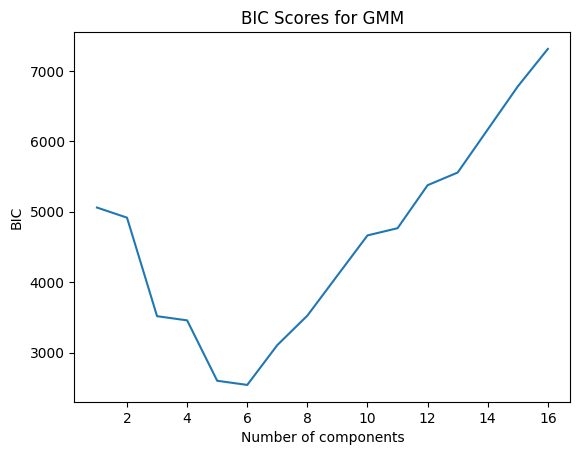

In [13]:
from sklearn.mixture import GaussianMixture

bic_scores = []
for n in range(1, 17):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(reduced_data)
    bic_scores.append(gmm.bic(reduced_data))

plt.plot(range(1, 17), bic_scores)
plt.title("BIC Scores for GMM")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.show()

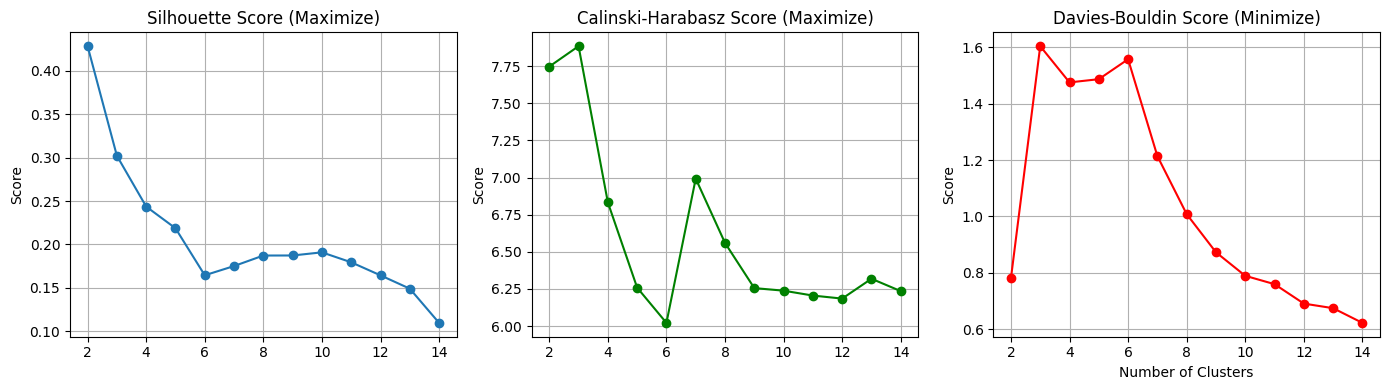

In [14]:
silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [15]:
gmm = GaussianMixture(n_components=6, random_state=42)
labels_gmm = gmm.fit_predict(reduced_data)

### Spectral Clustering

Best for `PCA` - 4 clusters (max score)

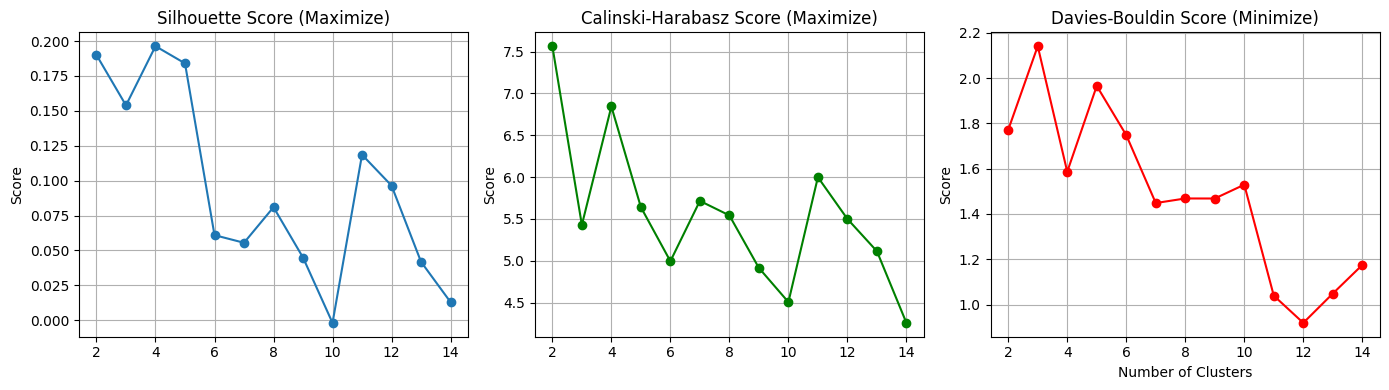

In [16]:
from sklearn.cluster import SpectralClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
    labels = spec.fit_predict(psds_array)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [17]:
spec = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
labels_spec_clust = spec.fit_predict(psds_array)

### Agglomerative

Best for `PCA` - 3 clusters (max score)

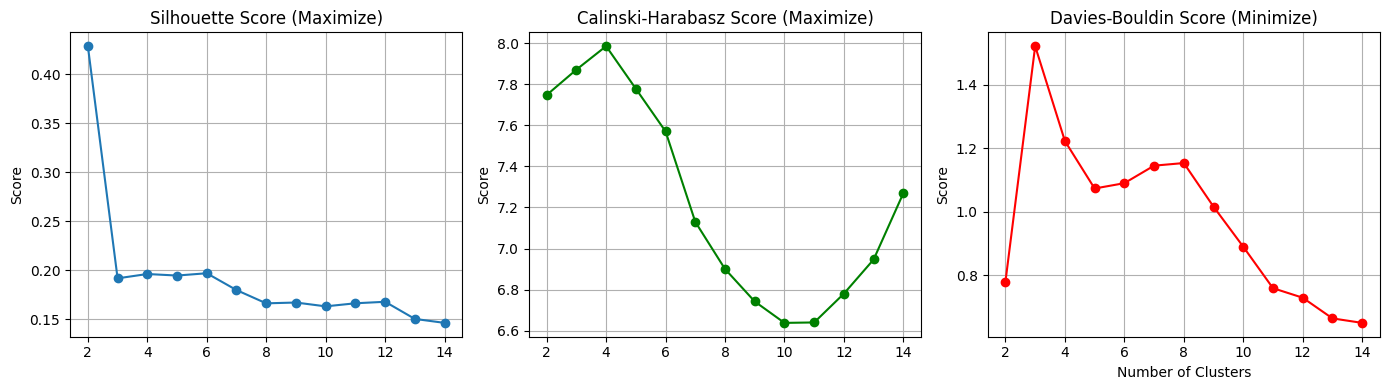

In [18]:
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Иерархическая кластеризация с заданным числом кластеров
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglomerative = model.fit_predict(reduced_data)

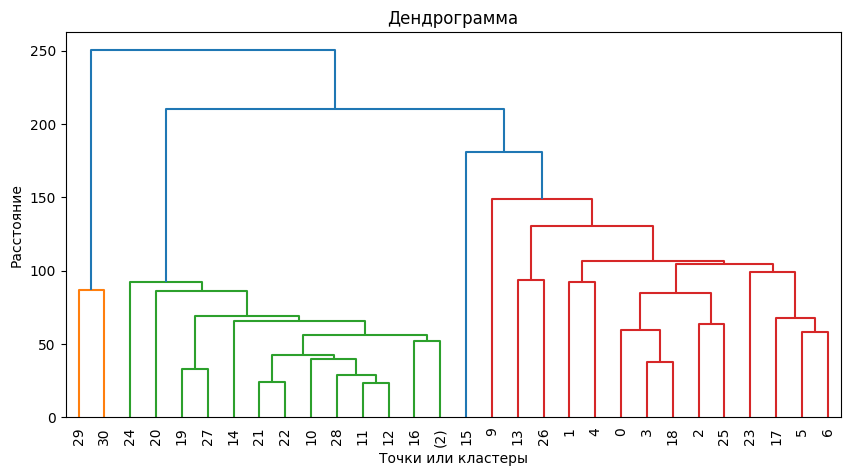

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(reduced_data, method='ward')  # метод linkage должен соответствовать
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90.)
plt.title('Дендрограмма')
plt.xlabel('Точки или кластеры')
plt.ylabel('Расстояние')
plt.show()

In [21]:
from datetime import datetime, time as dtime

# Используем тот же файл и приём, что в Compute_*_All
file_path = 'C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Supplementary/Experiment_Metadata.xlsx'
df_raw = pd.read_excel(file_path, header=1)

# Переименования как там
df_raw = df_raw.rename(columns={
    'Subject ID'     : 'Subject_id',
    'Имя'            : 'Name',
    'Фамилия'        : 'Surname',
    'Дата Рождения'  : 'Birthdate',
    'Пол'            : 'Gender',
    'Правша / Левша' : 'Handiness',
    'Время начала записи'  : 'Time',   
})

# Преобразование пола/латерализации в латиницу (как в compute_all)
gender_map = {'М':'m', 'Ж':'f', 'м':'m', 'ж':'f'}
if 'Gender' in df_raw.columns:
    df_raw['Gender'] = df_raw['Gender'].map(gender_map).fillna(df_raw['Gender'])

hand_map = {'Правша':'r', 'Левша':'l', 'правша':'r', 'левша':'l'}
if 'Handiness' in df_raw.columns:
    df_raw['Handiness'] = df_raw['Handiness'].map(hand_map).fillna(df_raw['Handiness'])

# Возраст (как в Compute): Birthdate -> Age и удаляем Birthdate
if 'Birthdate' in df_raw.columns:
    df_raw['Birthdate'] = pd.to_datetime(df_raw['Birthdate'], dayfirst=True, errors='coerce')
    today = pd.Timestamp.today().normalize()
    def calc_age(bd):
        if pd.isna(bd): return 0
        years = today.year - bd.year
        if (today.month, today.day) < (bd.month, bd.day): years -= 1
        return int(years)
    df_raw['Age'] = df_raw['Birthdate'].apply(calc_age).fillna(0).astype(int)
    df_raw = df_raw.drop(columns=['Birthdate'])

# Индекс — Subject_id
subject_metadata = df_raw.set_index('Subject_id')

# Парсинг времени: поддержка excel-чисел и строк/дат
def _to_time(series: pd.Series) -> pd.Series:
    if series.name is None:
        series.name = 'Time'
    s = series
    if np.issubdtype(s.dtype, np.number):
        vals = s.to_numpy(dtype=float)
        if np.nanmax(vals) <= 1.5:  # доля суток
            secs = np.nan_to_num(vals) * 24 * 3600.0
            return pd.to_timedelta(secs, unit='s').map(lambda td: (pd.Timestamp.min + td).time())
    dt = pd.to_datetime(s, errors='coerce')
    if dt.isna().any():
        raise ValueError("Часть значений времени не распарсилась (NaT). Проверь формат Time.")
    return dt.dt.time

# Находим колонку времени
time_col = 'Time' if 'Time' in subject_metadata.columns else None

subject_metadata['__time'] = _to_time(subject_metadata['Time'])
subject_metadata[['__time']].head()


,__time
Subject_id,
1,18:00:00
2,20:00:00
3,13:00:00
4,16:00:00
5,19:00:00


# Search Space Visualization

In [22]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 3
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 3)

In [23]:
# from sklearn.manifold import TSNE

# N = 3  # Размерность после снижения
# reducer = TSNE(n_components=N, random_state=42, perplexity=10, max_iter=10000, metric='euclidean')
# reduced_data = reducer.fit_transform(psds_array)

In [24]:
from plotly import colors as pc

method = 'PCA'
dim = 3  # Can be 2 or 3

subject_ids = [meta[0] for meta in metadata]
trial_ids = [meta[1] for meta in metadata]
gender = [meta[2] for meta in metadata]
handiness = [meta[3] for meta in metadata]
age = [meta[4] for meta in metadata]

# Маппим время к каждой записи по Subject_ID 
times = []
for sid in subject_ids:
    try:
        t = subject_metadata.loc[int(sid), '__time']
        # если у субъекта несколько строк в Excel — берём первую
        if isinstance(t, pd.Series):
            t = t.iloc[0]
        times.append(t)
    except Exception:
        times.append(None)

def _cond_from_time(t, day_start=10, day_end=18, eve_start=18, eve_end=24):
    if t is None:
        return 'other'
    h = int(t.hour)

    def in_window(a, b, h):
        # [a, b) с поддержкой обёртки через полночь; b может быть 24
        if a == b:
            return True  # весь круг
        if a < b:
            return a <= h < b
        # окно через полночь, например [22, 3)
        return (h >= a) or (h < b)

    if in_window(day_start, day_end, h):
        return 'day'
    if in_window(eve_start, eve_end, h):
        return 'evening'
    return 'other'

conditions = [_cond_from_time(t) for t in times]

# Adjust DataFrame columns based on dim
columns = [f'DIM-{i+1}' for i in range(dim)]
df = pd.DataFrame(reduced_data, columns=columns)
df['Subject_ID'] = subject_ids
df['Trial_ID'] = trial_ids
df['Gender'] = gender
df['Handiness'] = handiness
df['Age'] = age
df['Labels_DBSCAN'] = labels_dbscan
df['Labels_KNN'] = labels_knn
df['Labels_HDBSCAN'] = labels_hdbscan
df['Labels_GMM'] = labels_gmm
df['Labels_Spectral_Clustering'] = labels_spec_clust
df['Labels_Agglomerative'] = labels_agglomerative
df['Metadata'] = [str(meta) for meta in metadata]

df['Time'] = [t.strftime('%H:%M') if t is not None else None for t in times]  
df['Condition'] = conditions 

_CAT_PALETTE = (pc.qualitative.Plotly + pc.qualitative.D3 +
                pc.qualitative.Safe + pc.qualitative.Set3 +
                pc.qualitative.Pastel)

def _color_kwargs(series: pd.Series):
    s = pd.Series(series)

    if pd.api.types.is_numeric_dtype(s):
        return {'color': s.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    s_str = s.astype(str)

    # формат времени 'HH:MM' - переводим в минуты суток
    if s_str.dropna().str.match(r'^\d{1,2}:\d{2}$').all():
        dt = pd.to_datetime(s_str, format='%H:%M', errors='coerce')
        mins = (dt.dt.hour * 60 + dt.dt.minute).astype(float)
        return {'color': mins.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    # категориальные значения - дискретные цвета
    cats = s_str.fillna('NA').unique()
    lut = {cat: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, cat in enumerate(cats)}
    mapped = s_str.fillna('NA').map(lut)
    return {'color': mapped.to_numpy()}

coloring_vars = [
    'Subject_ID', 'Trial_ID', 'Gender', 'Handiness', 'Age',
    'Labels_DBSCAN', 'Labels_KNN', 'Labels_HDBSCAN', 'Labels_GMM',
    'Labels_Spectral_Clustering', 'Labels_Agglomerative',
    'Condition', 'Time'
]

fig = go.Figure()

for i, var in enumerate(coloring_vars):
    if var not in df.columns:
        continue

    mkw = _color_kwargs(df[var])  # корректные параметры для marker

    if dim == 3:
        fig.add_trace(go.Scatter3d(
            x=df['DIM-1'], y=df['DIM-2'], z=df['DIM-3'],
            mode='markers',
            marker=dict(size=4, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)  # показываем первый слой по умолчанию
        ))
    else:
        fig.add_trace(go.Scatter(
            x=df['DIM-1'], y=df['DIM-2'],
            mode='markers',
            marker=dict(size=6, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)
        ))

buttons = []
for i, var in enumerate(coloring_vars):
    buttons.append(dict(
        label=var,
        method='update',
        args=[{'visible': [j == i for j in range(len(coloring_vars))]}]
    ))

if dim == 3:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        scene=dict(
            xaxis_title=f'{method}-1',
            yaxis_title=f'{method}-2',
            zaxis_title=f'{method}-3'
        ),
        showlegend=False
    )
else:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        xaxis_title=f'{method}-1',
        yaxis_title=f'{method}-2',
        showlegend=False
    )

fig.show()

#fig.write_html(f'./Generated/Figures/Spectral_Analysis/Spectral_Clustering/All/Morlet_PCA_All_Clust_3D.html', include_plotlyjs='cdn', full_html=True)

In [25]:
# параметры анализа
EMBEDDING_MODE = 'raw'     # 'raw' (без DR), 'pca_keep' (мягкая PCA), 'pca_ready' (reduced_data)
PCA_KEEP_N     = 8         # число компонент при 'pca_keep'
DISTANCE       = 'cosine'  # 'cosine' или 'euclidean' для метрики центроидов
N_CLUSTERS     = 4         # кластеры в каждом условии для варианта A
N_NEIGHBORS    = 15        # граф соседей для SpectralClustering
K_GLOBAL       = 6         # число кластеров для глобального KMeans в варианте B
RANDOM_STATE   = 42
N_PERM         = 500       # число перестановок (0 — отключить)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, ks_2samp, mannwhitneyu
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import os

def select_embedding(psds_array, reduced_data, mode='raw', keep_n=8, seed=42):
    if mode == 'raw':
        Z = psds_array
        tag = f'RAW (dims={Z.shape[1]})'
    elif mode == 'pca_keep':
        pca = PCA(n_components=min(keep_n, psds_array.shape[1]), random_state=seed)
        Z = pca.fit_transform(psds_array)
        tag = f'PCA_keep (n={Z.shape[1]})'
    else:
        Z = reduced_data
        tag = f'PCA_ready (n={Z.shape[1]})'
    return Z, tag

def spectral_labels(X, k, n_neighbors, seed):
    nn = min(max(5, n_neighbors), max(5, X.shape[0]-1))
    k = min(k, max(2, X.shape[0]//2))  # не больше половины выборки
    model = SpectralClustering(
        n_clusters=k, affinity='nearest_neighbors',
        n_neighbors=nn, assign_labels='kmeans', random_state=seed
    )
    return model.fit_predict(X), k

def centroids(X, y):
    labs = sorted(np.unique(y))
    return np.vstack([X[y==lab].mean(axis=0) for lab in labs])

def match_distance(C1, C2, metric='cosine'):
    D = cosine_distances(C1, C2) if metric == 'cosine' else euclidean_distances(C1, C2)
    r, c = linear_sum_assignment(D)
    return D, r, c, float(D[r, c].mean())

def rbf_mmd2_unbiased(X, Y, gamma):
    XX = np.exp(-gamma * euclidean_distances(X, X, squared=True))
    YY = np.exp(-gamma * euclidean_distances(Y, Y, squared=True))
    XY = np.exp(-gamma * euclidean_distances(X, Y, squared=True))
    n, m = len(X), len(Y)
    if n < 2 or m < 2: 
        return np.nan
    np.fill_diagonal(XX, 0.0)
    np.fill_diagonal(YY, 0.0)
    term_xx = XX.sum() / (n*(n-1))
    term_yy = YY.sum() / (m*(m-1))
    term_xy = 2.0 * XY.mean()
    return float(term_xx + term_yy - term_xy)



In [27]:
# Z и тэг
Z, used_space = select_embedding(psds_array, reduced_data, EMBEDDING_MODE, PCA_KEEP_N, RANDOM_STATE)

conds = df['Condition'].astype(str).to_numpy()
mask_day = (conds == 'day')
mask_eve = (conds == 'evening')

print(f"Space: {used_space}. Samples: day={mask_day.sum()}, evening={mask_eve.sum()} (total={len(Z)})")


Space: RAW (dims=5040). Samples: day=17, evening=14 (total=31)


Вариант 1: KNN, считаем расстояние между центрами кластеров 

In [ ]:
resA = {}

if (mask_day.sum() >= max(2, N_CLUSTERS)) and (mask_eve.sum() >= max(2, N_CLUSTERS)):
    Z_day, Z_eve = Z[mask_day], Z[mask_eve]

    y_day, _ = spectral_labels(Z_day, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE)
    y_eve, _ = spectral_labels(Z_eve, N_CLUSTERS, N_NEIGHBORS, RANDOM_STATE)

    C_day = centroids(Z_day, y_day)
    C_eve = centroids(Z_eve, y_eve)

    Dmat, _, _, mean_min = match_distance(C_day, C_eve, DISTANCE)
    print(f"[A] Mean matched centroid distance (day-evening): {mean_min:.4f} | metric={DISTANCE}")
    resA.update({'mean': float(mean_min), 'D': Dmat})
    
    if N_PERM > 0:
        rng  = np.random.default_rng(RANDOM_STATE)
        nD, nE = len(Z_day), len(Z_eve)
        Xall = np.vstack([Z_day, Z_eve])
        count_ge = 0  # сколько раз mv >= наблюдаемого mean_min

        for _ in range(N_PERM):
            idx = rng.permutation(len(Xall))
            X1, X2 = Xall[idx[:nD]], Xall[idx[nD:nD+nE]]
            seed1 = int(rng.integers(0, 2**31-1))
            seed2 = int(rng.integers(0, 2**31-1))
            y1, _ = spectral_labels(X1, N_CLUSTERS, N_NEIGHBORS, seed1)
            y2, _ = spectral_labels(X2, N_CLUSTERS, N_NEIGHBORS, seed2)
            C1, C2 = centroids(X1, y1), centroids(X2, y2)
            _, _, _, mv = match_distance(C1, C2, DISTANCE)
            if mv >= mean_min:
                count_ge += 1

        p_ge = (1 + count_ge) / (N_PERM + 1)
        print(f"[A] permutation p-value (>=obs): {p_ge:.4f}")
        resA['p_perm'] = float(p_ge)

    fig = plt.figure(figsize=(4,3))
    plt.imshow(Dmat, aspect='auto')
    plt.title('Centroid distances: Day vs Evening')
    plt.xlabel('Evening clusters'); plt.ylabel('Day clusters')
    plt.colorbar(); plt.tight_layout(); plt.show()
    maybe_save(fig, 'A_centroid_distance_matrix.png')
    plt.close(fig)

else:
    print("[A] Недостаточно точек для заданного N_CLUSTERS — пропуск.")


[A] Mean matched centroid distance (day-evening): 0.8819 | metric=cosine


### Вариант 3

In [29]:
X_day, X_eve = Z[mask_day], Z[mask_eve]
resC1 = {}

if len(X_day) >= 2 and len(X_eve) >= 2:
    X_all = np.vstack([X_day, X_eve])
    # медиана попарных квадратов расстояний (вне диагонали)
    pair_d2 = euclidean_distances(X_all, squared=True)
    med = np.median(pair_d2[np.triu_indices_from(pair_d2, k=1)])
    gamma = 1.0 / (med + 1e-12)   # (или gamma = 0.5 / (med + 1e-12))

    mmd_obs = rbf_mmd2_unbiased(X_day, X_eve, gamma)
    p_mmd = None

    if N_PERM > 0 and np.isfinite(mmd_obs):
        rng = np.random.default_rng(RANDOM_STATE + 123)
        nD = len(X_day)
        count_ge = 0
        for _ in range(N_PERM):
            idx = rng.permutation(len(X_all))
            mv = rbf_mmd2_unbiased(X_all[idx[:nD]], X_all[idx[nD:]], gamma)
            if mv >= mmd_obs:
                count_ge += 1
        p_mmd = (1 + count_ge) / (N_PERM + 1)
        print(f"[C1] MMD^2 (RBF) = {mmd_obs:.4f}, permutation p = {p_mmd:.4f}")
    else:
        print(f"[C1] MMD^2 (RBF) = {mmd_obs:.4f} (перестановки отключены или мало точек)")

    resC1['mmd'] = float(mmd_obs)
    resC1['p']   = None if p_mmd is None else float(p_mmd)
else:
    print("[C1] одна из групп пуста или слишком мала — пропуск.")


[C1] MMD^2 (RBF) = 0.0762, permutation p = 0.0060


In [30]:
mask_de = mask_day | mask_eve
y_bin   = mask_eve[mask_de].astype(int)  # evening=1, day=0

# eigen + shrinkage → работает .transform/.fit_transform
lda  = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
proj = lda.fit_transform(Z[mask_de], y_bin).ravel()

proj_day = proj[y_bin == 0]
proj_eve = proj[y_bin == 1]

_, p_ks = ks_2samp(proj_day, proj_eve, alternative='two-sided', method='auto')
_, p_mw = mannwhitneyu(proj_day, proj_eve, alternative='two-sided')

print(f"[C2] LDA 1D: KS p = {p_ks:.4f}, Mann–Whitney p = {p_mw:.4f}")
resC2 = {'p_ks': float(p_ks), 'p_mw': float(p_mw)}


[C2] LDA 1D: KS p = 0.0000, Mann–Whitney p = 0.0000


In [31]:
summary = {
    "space": used_space,
    "variant_A": {k: (float(v) if isinstance(v, (np.floating,)) else v) for k, v in (resA or {}).items()},
    "variant_C1": resC1,
    "variant_C2": resC2
}
print(summary)


{'space': 'RAW (dims=5040)', 'variant_A': {'mean': 0.8819409136882473, 'D': array([[0.86153978, 0.9684222 , 1.30778701, 1.39745587],
       [1.63791223, 1.55053269, 0.90544601, 0.51200862],
       [1.360025  , 1.37645315, 0.9150349 , 0.86603068],
       [1.49443458, 1.44850142, 0.7777621 , 0.79318911]]), 'p_perm': 0.19560878243512975}, 'variant_C1': {'mmd': 0.07616847372450708, 'p': 0.005988023952095809}, 'variant_C2': {'p_ks': 7.54197509809517e-09, 'p_mw': 2.5540871152431474e-06}}


,feature,coef,abs_coef,std_coef,abs_std_coef,corr_score,abs_corr
0,f1248,-1.601101,1.601101,-1.601101,1.601101,-0.548767,0.548767
1,f1249,-1.600858,1.600858,-1.600858,1.600858,-0.548434,0.548434
2,f1247,-1.591668,1.591668,-1.591668,1.591668,-0.547973,0.547973
3,f1250,-1.595557,1.595557,-1.595557,1.595557,-0.547302,0.547302
4,f1246,-1.568569,1.568569,-1.568569,1.568569,-0.545783,0.545783
...,...,...,...,...,...,...,...
95,f136,-1.884314,1.884314,-1.884314,1.884314,-0.448137,0.448137
96,f3169,-0.105273,0.105273,-0.105273,0.105273,-0.447775,0.447775
97,f2273,-0.662057,0.662057,-0.662057,0.662057,-0.447737,0.447737
98,f3172,0.014361,0.014361,0.014361,0.014361,-0.447018,0.447018


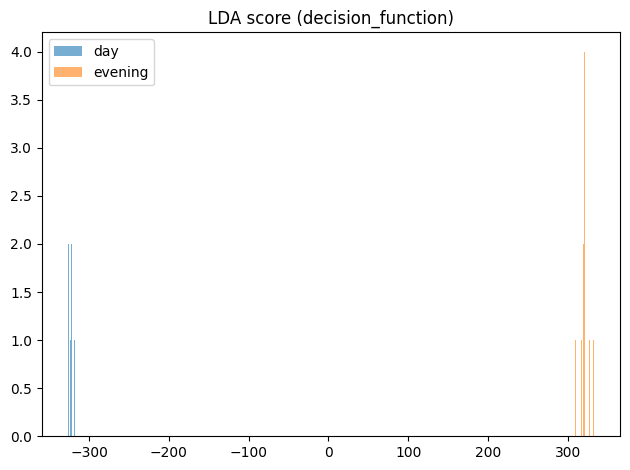

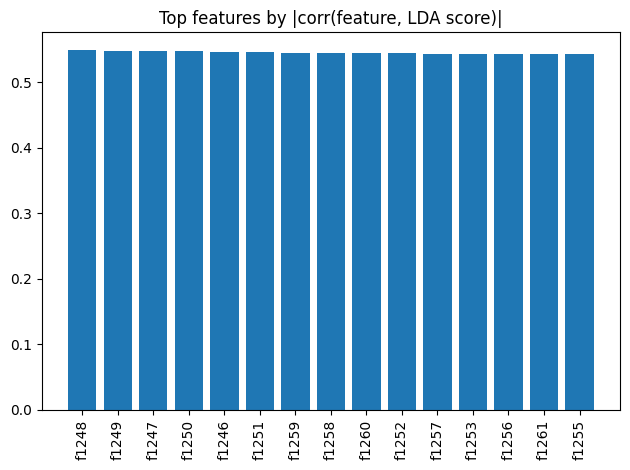

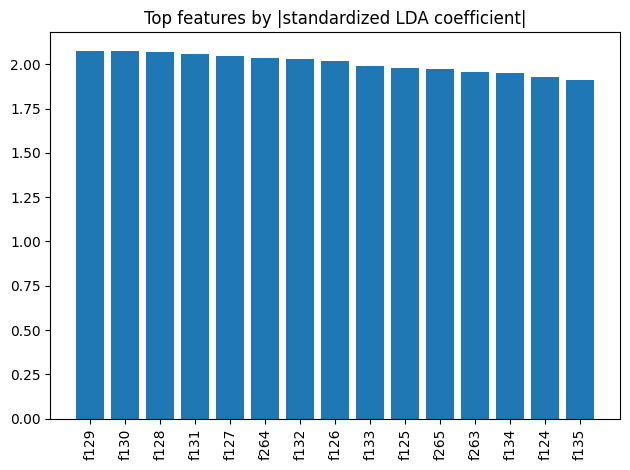

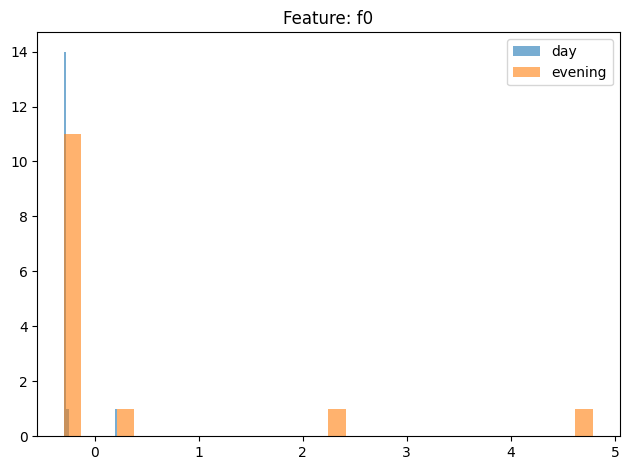

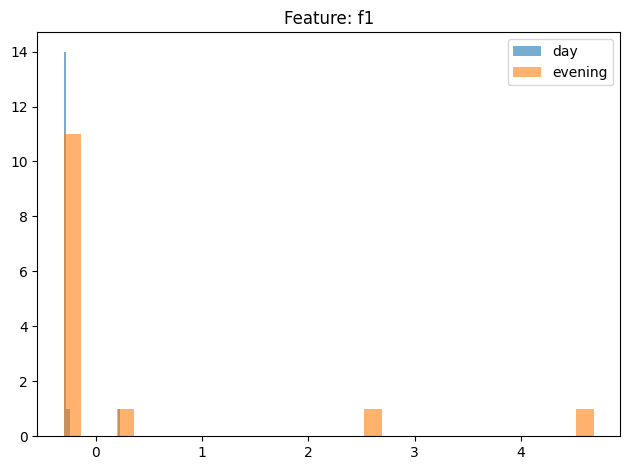

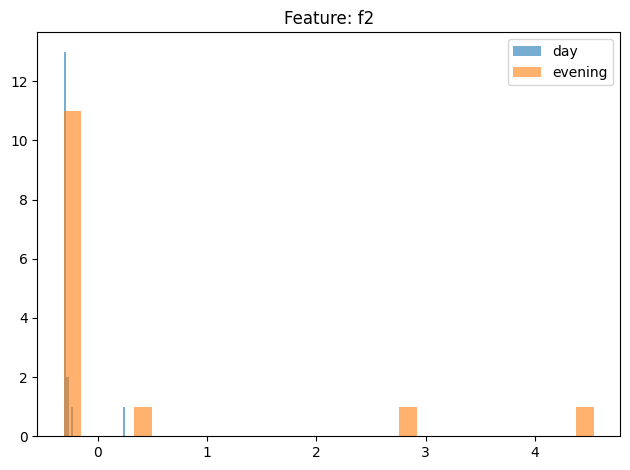

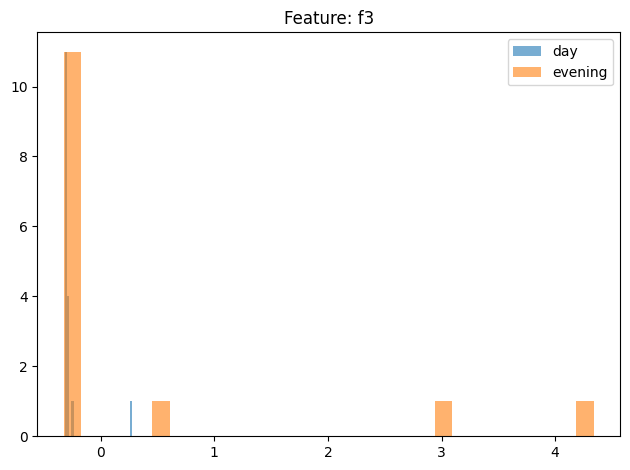

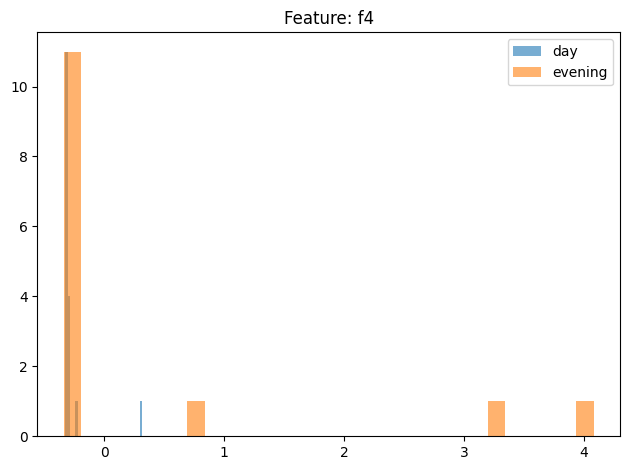

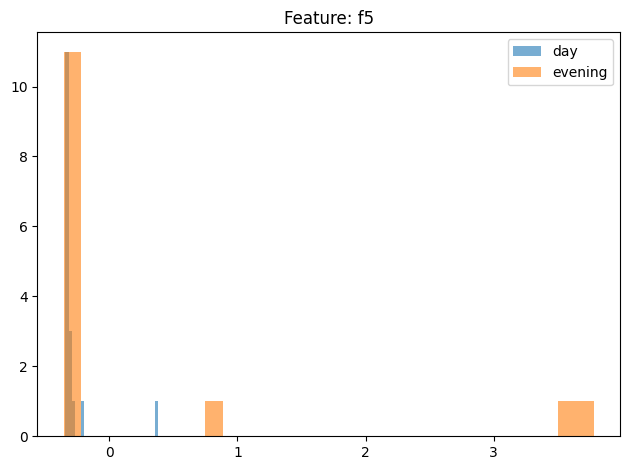

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ---- входные данные: Z, mask_day, mask_eve ----
# Z: np.ndarray или pd.DataFrame (n_samples x n_features)
# mask_day, mask_eve: булевы маски длины n_samples

# соберём фичи и имена
if isinstance(Z, pd.DataFrame):
    X_all = Z.values
    feat_names = list(Z.columns)
else:
    X_all = np.asarray(Z)
    feat_names = [f"f{i}" for i in range(X_all.shape[1])]

mask_de = (mask_day | mask_eve)
X = X_all[mask_de]
y = mask_eve[mask_de].astype(int)   # evening=1, day=0

# проверка на минимальный размер классов
n0, n1 = (y == 0).sum(), (y == 1).sum()
if n0 < 2 or n1 < 2:
    raise ValueError("Слишком мало наблюдений в одном из классов (нужно ≥2).")

# --- LDA: стабильный решатель с shrinkage; transform для lsqr недоступен, берём decision_function ---
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X, y)
score = np.asarray(lda.decision_function(X)).ravel()   # 1D LDA-скор
w = np.asarray(lda.coef_).ravel()                      # коэффициенты (направление разделения)

# --- метрики вклада признаков ---
# стандартизованные коэффициенты (учитывают масштаб фичи)
X_std = X.std(axis=0, ddof=0)
std_coef = w * X_std

# структурные коэффициенты: corr(feature_j, score)
Xm = X - X.mean(axis=0)
sm = score - score.mean()
den_x = np.sqrt((Xm**2).sum(axis=0)) + 1e-12
den_s = np.sqrt((sm**2).sum()) + 1e-12
corr = (Xm * sm[:, None]).sum(axis=0) / (den_x * den_s)
corr = np.where(np.isfinite(corr), corr, 0.0)

# собираем таблицу и сортируем по |corr|
imp = pd.DataFrame({
    "feature": feat_names,
    "coef": w,
    "abs_coef": np.abs(w),
    "std_coef": std_coef,
    "abs_std_coef": np.abs(std_coef),
    "corr_score": corr,
    "abs_corr": np.abs(corr),
}).sort_values("abs_corr", ascending=False).reset_index(drop=True)

# покажем топ-30 признаков
try:
    from IPython.display import display
    display(imp.head(100))
except Exception:
    print(imp.head(100).to_string(index=False))

# -------- ГРАФИКИ --------
TOPK_BAR = 15     # сколько признаков на bar-графиках
TOPK_HIST = 6     # сколько признаков рисовать гистограммами day vs evening
BINS = 30

# 1) LDA-скор: день vs вечер
score_day = score[y == 0]
score_eve = score[y == 1]
plt.figure()
plt.hist(score_day, bins=BINS, alpha=0.6, label="day")
plt.hist(score_eve, bins=BINS, alpha=0.6, label="evening")
plt.title("LDA score (decision_function)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) bar-график: топ по |corr|
idx_corr = np.argsort(-imp["abs_corr"].values)[:TOPK_BAR]
plt.figure()
plt.bar(range(len(idx_corr)), imp["abs_corr"].values[idx_corr])
plt.xticks(range(len(idx_corr)), [imp["feature"][i] for i in idx_corr], rotation=90)
plt.title("Top features by |corr(feature, LDA score)|")
plt.tight_layout()
plt.show()

# 3) bar-график: топ по |std_coef|
idx_std = np.argsort(-imp["abs_std_coef"].values)[:TOPK_BAR]
plt.figure()
plt.bar(range(len(idx_std)), imp["abs_std_coef"].values[idx_std])
plt.xticks(range(len(idx_std)), [imp["feature"][i] for i in idx_std], rotation=90)
plt.title("Top features by |standardized LDA coefficient|")
plt.tight_layout()
plt.show()

# 4) гистограммы распределений по топ-фичам (по критерию |corr|)
for j in idx_corr[:TOPK_HIST]:
    plt.figure()
    plt.hist(X[y == 0, j], bins=BINS, alpha=0.6, label="day")
    plt.hist(X[y == 1, j], bins=BINS, alpha=0.6, label="evening")
    plt.title(f"Feature: {feat_names[j]}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [33]:
import numpy as np
import pandas as pd

# --- 1) загрузка и сбор данных, как у тебя ---
loaded = np.load(
    'C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Generated/Spectrums/psds_array_morlet.npz',
    allow_pickle=True
)

results_arr = []
i = 0
while f'psd_{i}' in loaded:
    psd = loaded[f'psd_{i}']
    s_id = int(loaded[f'subject_id_{i}'])
    t_id = int(loaded[f'trial_id_{i}'])
    gender = str(loaded[f'gender_{i}'])
    handiness = str(loaded[f'handiness_{i}'])
    age = int(loaded[f'age_{i}'])
    results_arr.append([psd, s_id, t_id, gender, handiness, age])
    i += 1

psd0, *_ = results_arr[0]
shape = psd0.shape  # исходная форма PSD одного примера (до векторизации)

# --- 2) попытка вытащить подписи осей из .npz (частоты/каналы/время) ---
# эвристики: ищем массивы чилл-имен, частот и временных меток, совпадающих по длине с размерностями shape
keys = list(loaded.keys())

def _pick_label_for_dim(dim_len, prefer_keys):
    # сначала по "предпочтительным" ключам
    for k in prefer_keys:
        if k in loaded and getattr(loaded[k], "ndim", 1) == 1 and len(loaded[k]) == dim_len:
            return k, loaded[k]
    # затем по всем ключам с нужной длиной
    for k in keys:
        try:
            arr = loaded[k]
            if getattr(arr, "ndim", 1) == 1 and len(arr) == dim_len:
                return k, arr
        except Exception:
            pass
    return None, None

axis_labels = []
axis_names  = []  # подписи осей для печати

for ax, dim in enumerate(shape):
    # предполагаем типы осей по приоритету: channel, freq, time
    # пробуем найти "каналы"
    k, arr = _pick_label_for_dim(dim, prefer_keys=("ch_names","channels","ch","chan_names"))
    if arr is not None and (arr.dtype.kind in ("U","S","O")):
        axis_labels.append([str(x) for x in list(arr)])
        axis_names.append("channel")
        continue

    # пробуем найти "частоты"
    k, arr = _pick_label_for_dim(dim, prefer_keys=("freqs","frequency","f_grid","hz"))
    if arr is not None and np.issubdtype(getattr(arr, "dtype", np.float64), np.number):
        axis_labels.append([f"{float(x):.3f} Hz" for x in np.array(arr).astype(float)])
        axis_names.append("freq")
        continue

    # пробуем найти "время"
    k, arr = _pick_label_for_dim(dim, prefer_keys=("times","time","t","epochs","windows"))
    if arr is not None and np.issubdtype(getattr(arr, "dtype", np.float64), np.number):
        axis_labels.append([f"{float(x):.3f} s" for x in np.array(arr).astype(float)])
        axis_names.append("time")
        continue

    # заглушка, если ничего не нашли
    axis_labels.append([f"{ax}_{j}" for j in range(dim)])
    axis_names.append(f"axis{ax}")

# --- 3) функция: индекс признака -> «человеческое» имя (учитываем C-order, как при reshape) ---
def feature_name_from_flat_index(j, base_shape, axis_labels, axis_names, order="C"):
    multi_idx = np.unravel_index(int(j), base_shape, order=order)
    parts = []
    for ax, idx in enumerate(multi_idx):
        label = axis_labels[ax][idx] if idx < len(axis_labels[ax]) else str(idx)
        parts.append(f"{axis_names[ax]}={label}")
    return " | ".join(parts)

# --- 4) напечатаем имена для f1244..f1271 ---
start, end = 1244, 1271  # включительно
rows = []
for j in range(start, end+1):
    rows.append((j, feature_name_from_flat_index(j, shape, axis_labels, axis_names, order="C")))
mapping_df = pd.DataFrame(rows, columns=["flat_index", "decoded_name"])

# красиво выводим
try:
    from IPython.display import display
    display(mapping_df)
except Exception:
    print(mapping_df.to_string(index=False))

# (опционально) сохранить в CSV
# mapping_df.to_csv("feature_names_1244_1271.csv", index=False, encoding="utf-8")



,flat_index,decoded_name
0,1244,axis0=0_15 | axis1=1_44
1,1245,axis0=0_15 | axis1=1_45
2,1246,axis0=0_15 | axis1=1_46
3,1247,axis0=0_15 | axis1=1_47
4,1248,axis0=0_15 | axis1=1_48
5,1249,axis0=0_15 | axis1=1_49
6,1250,axis0=0_15 | axis1=1_50
7,1251,axis0=0_15 | axis1=1_51
8,1252,axis0=0_15 | axis1=1_52
9,1253,axis0=0_15 | axis1=1_53


Samples: day=17, evening=14, features=28
[HOLDOUT] acc=0.5714  bal-acc=0.6250  auc=0.5833
Confusion matrix:
 [[1 3]
 [0 3]]
              precision    recall  f1-score   support

           0     1.0000    0.2500    0.4000         4
           1     0.5000    1.0000    0.6667         3

    accuracy                         0.5714         7
   macro avg     0.7500    0.6250    0.5333         7
weighted avg     0.7857    0.5714    0.5143         7

[CV-5] acc=0.7095±0.2205  bal-acc=0.7167±0.2211  auc=0.6889±0.2266
[LDA-score] KS p=4.937e-03  Mann–Whitney p=3.528e-03


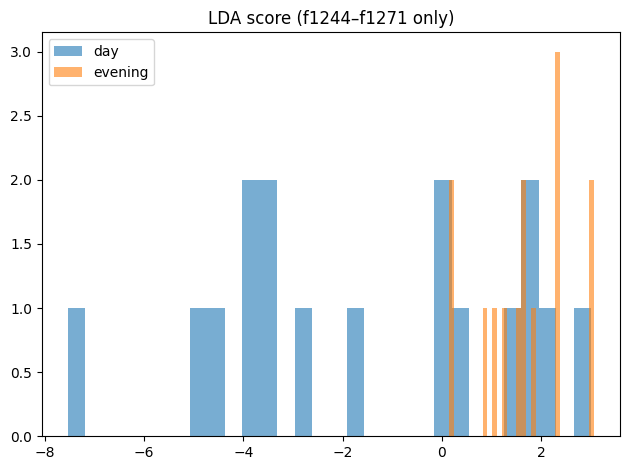

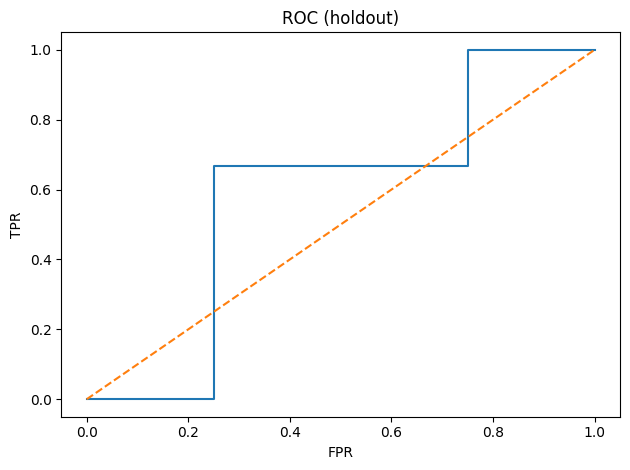

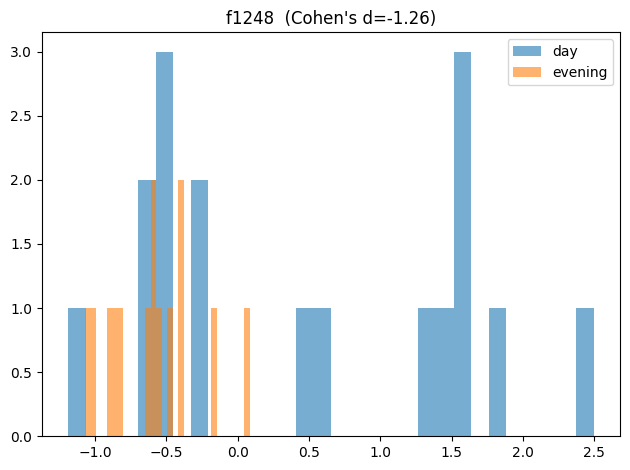

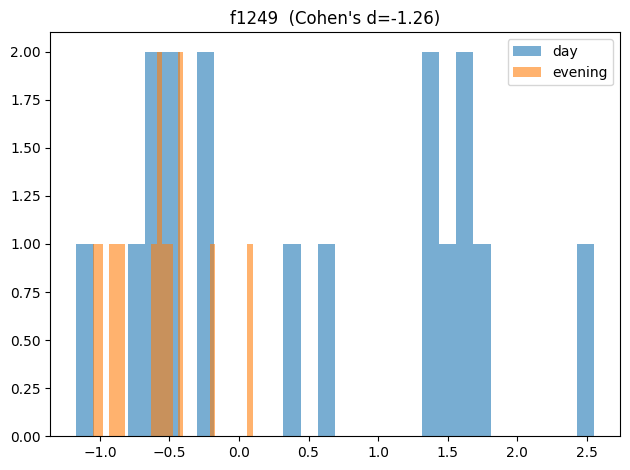

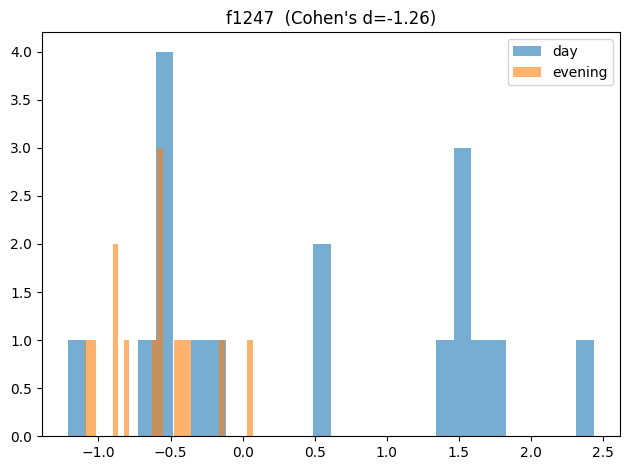

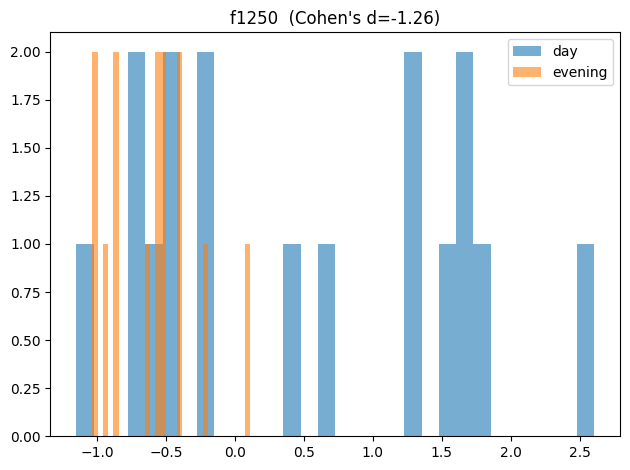

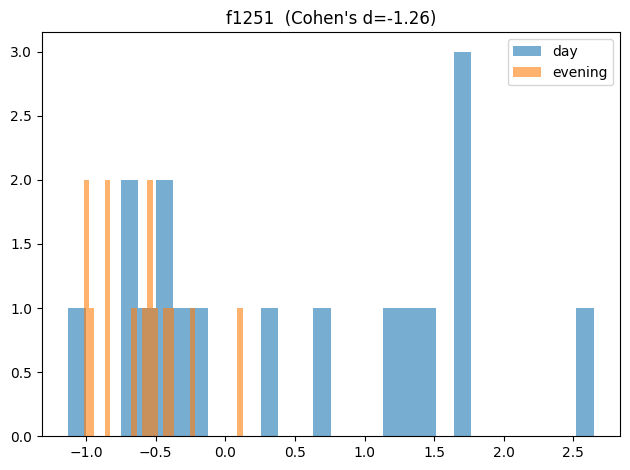

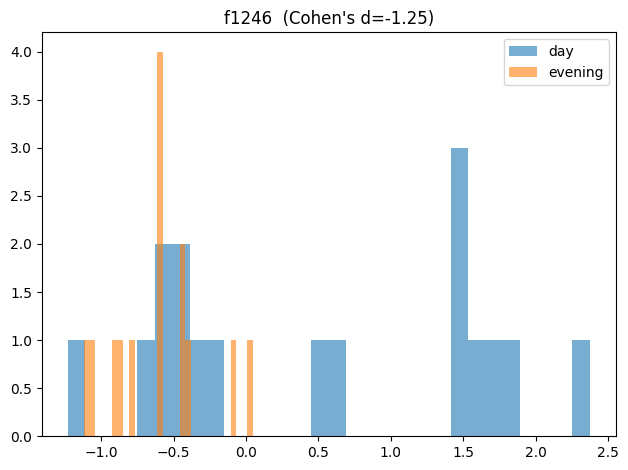

,feature,mu_day,mu_eve,cohen_d
0,f1248,0.494983,-0.601051,-1.264802
1,f1249,0.494684,-0.600688,-1.263713
2,f1247,0.494261,-0.600174,-1.262175
3,f1250,0.493664,-0.599449,-1.260010
4,f1251,0.492292,-0.597784,-1.255047
5,f1246,0.492269,-0.597756,-1.254964
6,f1259,0.491532,-0.596860,-1.252303
7,f1258,0.491240,-0.596505,-1.251250
8,f1260,0.491210,-0.596469,-1.251142
9,f1252,0.490959,-0.596165,-1.250240


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from scipy.stats import ks_2samp, mannwhitneyu

# --- 1) данные и подвыборка признаков ---
idx = np.arange(1244, 1272)                 # f1244..f1271 включительно (28 фич)
mask_de = (mask_day | mask_eve)
X = Z[mask_de][:, idx]
y = mask_eve[mask_de].astype(int)           # evening=1, day=0

feat_names = [f"f{i}" for i in idx]         # если есть «человеческие» имена — подставь сюда

# проверка размеров классов
n0, n1 = (y==0).sum(), (y==1).sum()
print(f"Samples: day={n0}, evening={n1}, features={X.shape[1]}")

# --- 2) holdout + модель ---
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
pipe.fit(Xtr, ytr)

# метрики на holdout
yhat = pipe.predict(Xte)
proba = pipe.predict_proba(Xte)[:, 1]
print("[HOLDOUT] acc=%.4f  bal-acc=%.4f  auc=%.4f" % (
    accuracy_score(yte, yhat), balanced_accuracy_score(yte, yhat), roc_auc_score(yte, proba)
))
print("Confusion matrix:\n", confusion_matrix(yte, yhat))
print(classification_report(yte, yhat, digits=4))

# --- 3) CV-метрики (без утечки: StandardScaler внутри пайплайна) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
acc_cv = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
auc_cv = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
bal_cv = cross_val_score(pipe, X, y, cv=cv, scoring="balanced_accuracy")
print("[CV-5] acc=%.4f±%.4f  bal-acc=%.4f±%.4f  auc=%.4f±%.4f" % (
    acc_cv.mean(), acc_cv.std(), bal_cv.mean(), bal_cv.std(), auc_cv.mean(), auc_cv.std()
))

# --- 4) одномерная проекция (LDA-score) и тесты ---
score_all = pipe.decision_function(X)          # pipeline пробрасывает метод к LDA
score_day = score_all[y==0]
score_eve = score_all[y==1]

_, p_ks = ks_2samp(score_day, score_eve, alternative='two-sided', method='auto')
_, p_mw = mannwhitneyu(score_day, score_eve, alternative='two-sided')
print(f"[LDA-score] KS p={p_ks:.3e}  Mann–Whitney p={p_mw:.3e}")

# --- 5) графики: LDA-score (гист), ROC, гистограммы по топ-фичам из этого диапазона ---
# 5.1 LDA-score: day vs evening
plt.figure()
plt.hist(score_day, bins=30, alpha=0.6, label="day")
plt.hist(score_eve, bins=30, alpha=0.6, label="evening")
plt.title("LDA score (f1244–f1271 only)")
plt.legend()
plt.tight_layout()
plt.show()

# 5.2 ROC (на holdout)
fpr, tpr, _ = roc_curve(yte, proba)
plt.figure()
plt.plot(fpr, tpr, label="ROC")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC (holdout)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.tight_layout()
plt.show()

# 5.3 гистограммы для топ-фич внутри диапазона (ранжируем по Cohen's d)
X_day, X_eve = X[y==0], X[y==1]
mu_day = X_day.mean(axis=0); mu_eve = X_eve.mean(axis=0)
sd_pooled = np.sqrt(((X_day.var(axis=0, ddof=1)*(len(X_day)-1) + 
                      X_eve.var(axis=0, ddof=1)*(len(X_eve)-1)) /
                     (len(X_day)+len(X_eve)-2)) + 1e-12)
cohen_d = (mu_eve - mu_day) / sd_pooled
order = np.argsort(-np.abs(cohen_d))

TOPK = 6  # сколько признаков показать гистограммами
for j in order[:TOPK]:
    plt.figure()
    plt.hist(X_day[:, j], bins=30, alpha=0.6, label="day")
    plt.hist(X_eve[:, j], bins=30, alpha=0.6, label="evening")
    ttl = f"{feat_names[j]}  (Cohen's d={cohen_d[j]:.2f})"
    plt.title(ttl)
    plt.legend()
    plt.tight_layout()
    plt.show()

# (опционально) таблица по всем 28 фичам
imp = pd.DataFrame({
    "feature": feat_names,
    "mu_day": mu_day, "mu_eve": mu_eve,
    "cohen_d": cohen_d
}).iloc[order].reset_index(drop=True)
try:
    from IPython.display import display
    display(imp)
except:
    print(imp.to_string(index=False))



In [35]:
from sklearn.preprocessing import StandardScaler
X_all = np.vstack([X_day, X_eve])
scaler = StandardScaler().fit(X_all)
X_day_s = scaler.transform(X_day)
X_eve_s = scaler.transform(X_eve)


In [36]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

def median_gamma(X, factor=1.0):
    d2 = euclidean_distances(X, squared=True)
    med = np.median(d2[np.triu_indices_from(d2, k=1)])
    return factor / (med + 1e-12)

factors = [0.25, 0.5, 1, 2, 4]
for f in factors:
    g = median_gamma(np.vstack([X_day_s, X_eve_s]), factor=f)
    mmd = rbf_mmd2_unbiased(X_day_s, X_eve_s, g)
    # быстрый p без хранения массива:
    rng = np.random.default_rng(RANDOM_STATE+777)
    Xall = np.vstack([X_day_s, X_eve_s]); nD = len(X_day_s)
    count_ge = 0
    for _ in range(N_PERM):
        idx = rng.permutation(len(Xall))
        mv = rbf_mmd2_unbiased(Xall[idx[:nD]], Xall[idx[nD:]], g)
        count_ge += (mv >= mmd)
    p = (1 + count_ge) / (N_PERM + 1)
    print(f"gamma=factor {f:<4}: MMD2={mmd:.4f}, p={p:.4f}")


gamma=factor 0.25: MMD2=0.3098, p=0.0060
gamma=factor 0.5 : MMD2=0.3041, p=0.0060
gamma=factor 1   : MMD2=0.2586, p=0.0040
gamma=factor 2   : MMD2=0.1986, p=0.0080
gamma=factor 4   : MMD2=0.1423, p=0.0200


In [37]:
# предположим, что у тебя уже есть: X_day_s, X_eve_s (после StandardScaler),
# gamma (например, при factor=1), N_PERM, RANDOM_STATE

rng  = np.random.default_rng(RANDOM_STATE + 999)
Xall = np.vstack([X_day_s, X_eve_s]); nD = len(X_day_s)

mmd_obs = rbf_mmd2_unbiased(X_day_s, X_eve_s, gamma)

# онлайн-оценка среднего и дисперсии (Welford)
mean0 = 0.0
M2 = 0.0
count_ge = 0
for t in range(1, N_PERM+1):
    idx = rng.permutation(len(Xall))
    mv = rbf_mmd2_unbiased(Xall[idx[:nD]], Xall[idx[nD:]], gamma)
    delta = mv - mean0
    mean0 += delta / t
    M2 += delta * (mv - mean0)
    count_ge += (mv >= mmd_obs)

var0 = M2 / max(N_PERM-1, 1)
sd0  = np.sqrt(max(var0, 1e-12))
p_perm = (1 + count_ge) / (N_PERM + 1)
z = (mmd_obs - mean0) / sd0

print(f"MMD^2={mmd_obs:.4f}, p_perm={p_perm:.4f}, null_mean={mean0:.4f}, null_sd={sd0:.4f}, z={z:.2f}")


MMD^2=0.0071, p_perm=0.0040, null_mean=0.0000, null_sd=0.0013, z=5.61


In [38]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd

# ---- вход: X_day, X_eve (numpy) ----
assert len(X_day) >= 2 and len(X_eve) >= 2

# 1) стандартизируем признаки (важно для честного сравнения по осям)
scaler = StandardScaler().fit(np.vstack([X_day, X_eve]))
Xd = scaler.transform(X_day)
Xe = scaler.transform(X_eve)
Xall = np.vstack([Xd, Xe])
nD, nE = len(Xd), len(Xe)

# 2) базовые расстояния
D2_all = euclidean_distances(Xall, squared=True)
D_all  = np.sqrt(D2_all + 1e-12)

# медианы для эвристик
med_d2 = np.median(D2_all[np.triu_indices_from(D2_all, k=1)])
med_d  = np.median(D_all[np.triu_indices_from(D_all, k=1)])

# 3) ядра (каждая функция возвращает K(X, Y))
def K_rbf(X, Y, gamma):
    # exp(-gamma * ||x - y||^2)
    d2 = euclidean_distances(X, Y, squared=True)
    return np.exp(-gamma * d2)

def K_laplacian(X, Y, gamma):
    # exp(-gamma * ||x - y||_2)  (можно заменить на L1, если хочешь)
    d = np.sqrt(euclidean_distances(X, Y, squared=True) + 1e-12)
    return np.exp(-gamma * d)

def K_imq(X, Y, c2=1.0, beta=0.5):
    # (c^2 + ||x - y||^2)^(-beta)   — «Cauchy/IMQ»
    d2 = euclidean_distances(X, Y, squared=True)
    return (c2 + d2)**(-beta)

def K_rq(X, Y, alpha=1.0, ell2=1.0):
    # (1 + ||x-y||^2 / (2 alpha ell^2))^{-alpha} — Rational Quadratic
    d2 = euclidean_distances(X, Y, squared=True)
    return (1.0 + d2 / (2.0 * alpha * ell2))**(-alpha)

def K_matern32(X, Y, ell=1.0):
    # ν=3/2: (1 + √3 r/ell) exp(-√3 r/ell)
    d = np.sqrt(euclidean_distances(X, Y, squared=True) + 1e-12)
    s = np.sqrt(3.0) * d / ell
    return (1.0 + s) * np.exp(-s)

# 4) несмещённая MMD^2 для произвольного ядра
def mmd2_unbiased(X, Y, Kfn):
    Kxx = Kfn(X, X)
    Kyy = Kfn(Y, Y)
    Kxy = Kfn(X, Y)

    m, n = len(X), len(Y)
    # суммы вне диагонали
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)
    term_x = Kxx.sum() / (m * (m - 1))
    term_y = Kyy.sum() / (n * (n - 1))
    term_xy = Kxy.mean()
    return term_x + term_y - 2.0 * term_xy

# 5) пермутационный p-value (онлайн, без хранения всей null-выборки)
def perm_pvalue(X, Y, Kfn, n_perm=1000, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    Xall = np.vstack([X, Y]); m = len(X)
    obs = mmd2_unbiased(X, Y, Kfn)
    count_ge = 0
    for _ in range(n_perm):
        idx = rng.permutation(len(Xall))
        Xp, Yp = Xall[idx[:m]], Xall[idx[m:]]
        mv = mmd2_unbiased(Xp, Yp, Kfn)
        if mv >= obs:
            count_ge += 1
    p = (1 + count_ge) / (n_perm + 1)
    return obs, p

# 6) параметры ядер по median heuristic и их набор
gamma_rbf = 1.0 / (med_d2 + 1e-12)
gamma_lap = 1.0 / (med_d  + 1e-12)
c2_imq    = med_d2
ell2_rq   = med_d2         # эквивалент ширины
ell_m32   = med_d          # длина для Matérn 3/2

kernels = {
    f"RBF(γ=1/med_d2)":   (lambda A,B: K_rbf(A,B, gamma_rbf)),
    f"Laplacian(γ=1/med_d)": (lambda A,B: K_laplacian(A,B, gamma_lap)),
    f"IMQ(C^2=med_d2, β=0.5)": (lambda A,B: K_imq(A,B, c2=c2_imq, beta=0.5)),
    f"RQ(α=1, ℓ^2=med_d2)":   (lambda A,B: K_rq(A,B, alpha=1.0, ell2=ell2_rq)),
    f"Matérn-3/2(ℓ=med_d)":   (lambda A,B: K_matern32(A,B, ell=ell_m32)),
}

# 7) MK-MMD: смесь нескольких RBF c разными γ (равные веса)
factors = [0.25, 0.5, 1.0, 2.0, 4.0]
gammas  = [gamma_rbf * f for f in factors]
def K_mk_rbf(A, B):
    K = np.zeros((len(A), len(B)))
    for g in gammas:
        K += K_rbf(A, B, g)
    return K / len(gammas)
kernels[f"MK-RBF({factors})"] = K_mk_rbf

# 8) прогоняем все ядра
rows = []
for name, Kfn in kernels.items():
    mmd2, p = perm_pvalue(Xd, Xe, Kfn, n_perm=N_PERM, rng_seed=RANDOM_STATE+2025)
    rows.append((name, mmd2, p))
    print(f"{name:24s}  MMD^2={mmd2:.5f}  p={p:.4f}")

summary = pd.DataFrame(rows, columns=["kernel", "MMD2_u", "p_perm"])\
            .sort_values("p_perm").reset_index(drop=True)
try:
    from IPython.display import display
    display(summary)
except:
    print(summary.to_string(index=False))


RBF(γ=1/med_d2)           MMD^2=0.25863  p=0.0080
Laplacian(γ=1/med_d)      MMD^2=0.20750  p=0.0080
IMQ(C^2=med_d2, β=0.5)    MMD^2=0.05845  p=0.0060
RQ(α=1, ℓ^2=med_d2)       MMD^2=0.25741  p=0.0060
Matérn-3/2(ℓ=med_d)       MMD^2=0.26452  p=0.0080
MK-RBF([0.25, 0.5, 1.0, 2.0, 4.0])  MMD^2=0.24269  p=0.0080


,kernel,MMD2_u,p_perm
0,"RQ(α=1, ℓ^2=med_d2)",0.257412,0.005988
1,"IMQ(C^2=med_d2, β=0.5)",0.058450,0.005988
2,Laplacian(γ=1/med_d),0.207496,0.007984
3,RBF(γ=1/med_d2),0.258626,0.007984
4,Matérn-3/2(ℓ=med_d),0.264523,0.007984
5,"MK-RBF([0.25, 0.5, 1.0, 2.0, 4.0])",0.242685,0.007984


Data: n=31, d=5040 | classes: day=17, evening=14, subjects=16
[info] AUC-скоры недоступны (best AUC is NaN/inf); используем balanced_accuracy.
Best C: 0.001 | CV balanced_accuracy=0.687
[GroupCV] acc=0.645  bal-acc=0.658  auc=0.601
Confusion matrix:
 [[ 9  8]
 [ 3 11]]
              precision    recall  f1-score   support

           0      0.750     0.529     0.621        17
           1      0.579     0.786     0.667        14

    accuracy                          0.645        31
   macro avg      0.664     0.658     0.644        31
weighted avg      0.673     0.645     0.641        31



,channel,chan_idx,freq_bin,freq_Hz,coef,abs_coef
0,ch15,15,61,61.0,-0.003851,0.003851
1,ch15,15,62,62.0,-0.003847,0.003847
2,ch15,15,60,60.0,-0.003846,0.003846
3,ch15,15,63,63.0,-0.003836,0.003836
4,ch15,15,59,59.0,-0.003834,0.003834
5,ch15,15,64,64.0,-0.003822,0.003822
6,ch15,15,58,58.0,-0.003815,0.003815
7,ch15,15,65,65.0,-0.003809,0.003809
8,ch15,15,66,66.0,-0.003801,0.003801
9,ch15,15,67,67.0,-0.003798,0.003798



Top channels by |coef| sum:
 channel  sum_abs_coef
   ch16      0.195982
    ch1      0.195154
   ch15      0.186054
   ch55      0.114975
   ch61      0.110930
   ch17      0.108223
   ch60      0.107801
   ch20      0.106925
   ch28      0.105499
    ch8      0.102440

Top frequencies by |coef| sum:
  freq_bin  freq_Hz  sum_abs_coef
       45     45.0      0.069079
       46     46.0      0.069012
       44     44.0      0.068723
       47     47.0      0.068598
       48     48.0      0.068049
       27     27.0      0.067936
       43     43.0      0.067924
       26     26.0      0.067760
       49     49.0      0.067605
       28     28.0      0.067115


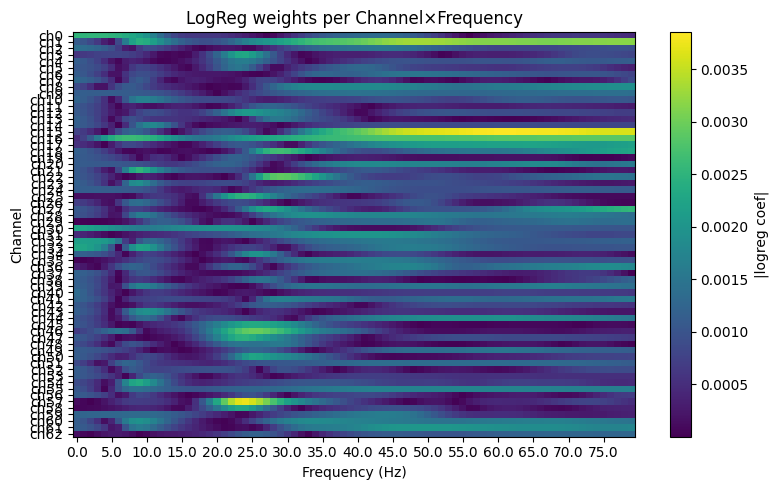

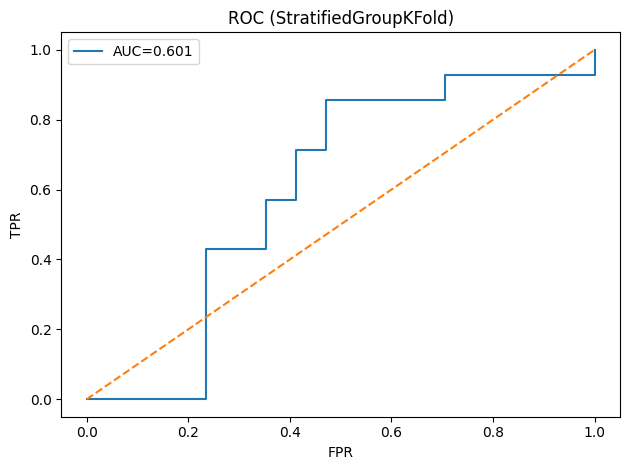

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# === данные ===
mask_de = (mask_day | mask_eve)
X = Z[mask_de]
y = mask_eve[mask_de].astype(int)  # evening=1, day=0
groups = np.array([item[1] for item in results_arr])[mask_de]  # subject_id

print(f"Data: n={len(X)}, d={X.shape[1]} | classes: day={(y==0).sum()}, evening={(y==1).sum()}, subjects={np.unique(groups).size}")

# === стратифицированные групповые сплиты ===
try:
    from sklearn.model_selection import StratifiedGroupKFold
    gkf = StratifiedGroupKFold(n_splits=min(5, np.unique(groups).size), shuffle=True, random_state=0)
except Exception:
    from sklearn.model_selection import GroupKFold
    print("[warn] StratifiedGroupKFold недоступен — падаем на GroupKFold (AUC может стать NaN).")
    gkf = GroupKFold(n_splits=min(5, np.unique(groups).size))

# === модель: L2 логрег (стабильная), без снижения размерности ===
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2", solver="lbfgs", max_iter=20000,
        class_weight="balanced", random_state=0, n_jobs=-1
    ))
])

param_grid = {"clf__C": np.logspace(-3, 3, 13)}

def fit_with_scoring(scoring):
    grid = GridSearchCV(pipe, param_grid, cv=gkf, scoring=scoring, n_jobs=-1, refit=True, error_score="raise")
    grid.fit(X, y, groups=groups)
    return grid

# пробуем по AUC; если рухнет/NaN, пробуем balanced_accuracy
try:
    grid = fit_with_scoring("roc_auc")
    if not np.isfinite(grid.best_score_):
        raise ValueError("best AUC is NaN/inf")
    metric_name = "AUC"
except Exception as e:
    print(f"[info] AUC-скоры недоступны ({e}); используем balanced_accuracy.")
    grid = fit_with_scoring("balanced_accuracy")
    metric_name = "balanced_accuracy"

print(f"Best C: {grid.best_params_['clf__C']} | CV {metric_name}={grid.best_score_:.3f}")

# === группово-стратифицированные предсказания для метрик/ROC ===
try:
    proba_cv = cross_val_predict(grid.best_estimator_, X, y, cv=gkf, groups=groups, method="predict_proba")[:,1]
except Exception:
    # если predict_proba недоступен — используем decision_function и приводим к [0,1]
    df = cross_val_predict(grid.best_estimator_, X, y, cv=gkf, groups=groups, method="decision_function")
    proba_cv = (df - df.min()) / (df.max() - df.min() + 1e-12)

y_pred_cv = (proba_cv >= 0.5).astype(int)

print("[GroupCV] acc=%.3f  bal-acc=%.3f  auc=%.3f" % (
    accuracy_score(y, y_pred_cv),
    balanced_accuracy_score(y, y_pred_cv),
    roc_auc_score(y, proba_cv)
))
print("Confusion matrix:\n", confusion_matrix(y, y_pred_cv))
print(classification_report(y, y_pred_cv, digits=3))

# === финальная модель на всех данных → веса признаков ===
est = grid.best_estimator_.fit(X, y)
w = est.named_steps["clf"].coef_.ravel()   # (d,)

# --- вытаскиваем (электрод×частота) из .npz ---
psd0 = results_arr[0][0]
base_shape = psd0.shape   # (n_channels, n_freqs)
assert np.prod(base_shape) == X.shape[1], f"Mismatch: {np.prod(base_shape)} != {X.shape[1]}"

def _pick_axis_labels(loaded, dim_len, prefer_keys, numeric_ok):
    for k in prefer_keys:
        if k in loaded and getattr(loaded[k], "ndim", 1) == 1 and len(loaded[k]) == dim_len:
            arr = np.array(loaded[k])
            if numeric_ok or arr.dtype.kind in ("U","S","O"):
                return arr
    for k in loaded.files:
        arr = np.array(loaded[k])
        if getattr(arr, "ndim", 1) == 1 and len(arr) == dim_len:
            if numeric_ok or arr.dtype.kind in ("U","S","O"):
                return arr
    return None

ch_names = _pick_axis_labels(loaded, base_shape[0], ("ch_names","channels","chan_names","ch"), numeric_ok=False)
freqs    = _pick_axis_labels(loaded, base_shape[1], ("freqs","frequency","f_grid","hz"), numeric_ok=True)
if ch_names is None: ch_names = np.array([f"ch{c}" for c in range(base_shape[0])], dtype=object)
if freqs is None:    freqs    = np.arange(base_shape[1], dtype=float)

W_cf = w.reshape(base_shape, order="C")
Wabs = np.abs(W_cf)

# ТОП-ячейки по |весу|
K = 12
flat_idx = np.argsort(Wabs.ravel())[::-1][:K]
rows = []
for j in flat_idx:
    c, f = np.unravel_index(j, base_shape, order="C")
    rows.append({
        "channel": str(ch_names[c]),
        "chan_idx": int(c),
        "freq_bin": int(f),
        "freq_Hz": float(freqs[f]) if np.issubdtype(type(freqs[f]), np.number) else np.nan,
        "coef": float(W_cf[c, f]),
        "abs_coef": float(Wabs[c, f]),
    })
top_cf = pd.DataFrame(rows)
try:
    from IPython.display import display
    display(top_cf)
except Exception:
    print(top_cf.to_string(index=False))

# агрегаты по каналам/частотам
imp_channels = pd.DataFrame({"channel": ch_names, "sum_abs_coef": Wabs.sum(axis=1)})\
                  .sort_values("sum_abs_coef", ascending=False).reset_index(drop=True)
imp_freqs = pd.DataFrame({"freq_bin": np.arange(base_shape[1]),
                          "freq_Hz": [float(x) if np.issubdtype(type(x), np.number) else np.nan for x in freqs],
                          "sum_abs_coef": Wabs.sum(axis=0)})\
               .sort_values("sum_abs_coef", ascending=False).reset_index(drop=True)

print("\nTop channels by |coef| sum:\n", imp_channels.head(10).to_string(index=False))
print("\nTop frequencies by |coef| sum:\n", imp_freqs.head(10).to_string(index=False))

# === (опц.) графики ===
PLOT = True
if PLOT:
    # теплокарта |весов|
    plt.figure(figsize=(8, 5))
    plt.imshow(Wabs, aspect="auto")
    plt.colorbar(label="|logreg coef|")
    plt.yticks(np.arange(len(ch_names)), ch_names)
    step = max(1, len(freqs)//16)
    xt = np.arange(0, len(freqs), step)
    xtlbl = [f"{float(freqs[i]):.1f}" if np.issubdtype(type(freqs[i]), np.number) else str(freqs[i]) for i in xt]
    plt.xticks(xt, xtlbl, rotation=0)
    plt.xlabel("Frequency (Hz)"); plt.ylabel("Channel")
    plt.title("LogReg weights per Channel×Frequency")
    plt.tight_layout(); plt.show()

    # ROC по CV
    fpr, tpr, _ = roc_curve(y, proba_cv)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y, proba_cv):.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (StratifiedGroupKFold)")
    plt.legend(); plt.tight_layout(); plt.show()


Data: n=31, d=5040 | day=17, evening=14, subjects=16
Best: {'clf__C': np.float64(0.1668100537200059), 'clf__l1_ratio': 0.2} | CV balanced_accuracy=0.695
[GroupCV] acc=0.645  bal-acc=0.664  auc=0.626
Confusion matrix:
 [[ 8  9]
 [ 2 12]]


,channel,chan_idx,freq_bin,freq_Hz,nz_rate,mean_abs_w,coef_final,sign
0,ch15,15,62,62.0,1.0,0.029184,-0.038827,day↑
1,ch15,15,63,63.0,1.0,0.027761,-0.037321,day↑
2,ch15,15,64,64.0,1.0,0.026035,-0.035464,day↑
3,ch15,15,65,65.0,1.0,0.024384,-0.033722,day↑
4,ch15,15,66,66.0,1.0,0.023057,-0.032424,day↑
5,ch15,15,47,47.0,1.0,0.019264,-0.028649,day↑
6,ch15,15,46,46.0,1.0,0.017304,-0.026777,day↑
7,ch28,28,32,32.0,1.0,0.015864,-0.039492,day↑
8,ch36,36,75,75.0,1.0,0.015535,-0.040970,day↑
9,ch36,36,74,74.0,1.0,0.014364,-0.039788,day↑



Top channels:
 channel  sum_abs_coef  mean_nz
   ch15      1.023408   0.4375
   ch36      0.755805   0.2150
    ch1      0.597913   0.3250
   ch16      0.427189   0.4900
   ch28      0.303155   0.2375
   ch31      0.268472   0.1125
   ch57      0.253271   0.0875
   ch27      0.213677   0.0750
   ch61      0.179043   0.2225
   ch22      0.173723   0.0700

Top frequencies:
  freq_bin  freq_Hz  sum_abs_coef  mean_nz
       24     24.0      0.144227 0.047619
       25     25.0      0.142494 0.057143
       46     46.0      0.121930 0.098413
       47     47.0      0.121312 0.095238
       23     23.0      0.118723 0.041270
       45     45.0      0.117712 0.107937
       48     48.0      0.116983 0.082540
       49     49.0      0.111850 0.076190
       79     79.0      0.108728 0.095238
       78     78.0      0.108674 0.092063

Bands importance:
  band  sum_abs_coef  mean_nz
gamma      3.251449 0.075184
other      0.876839 0.082222
 beta      0.790022 0.026517
alpha      0.167718 0.0526

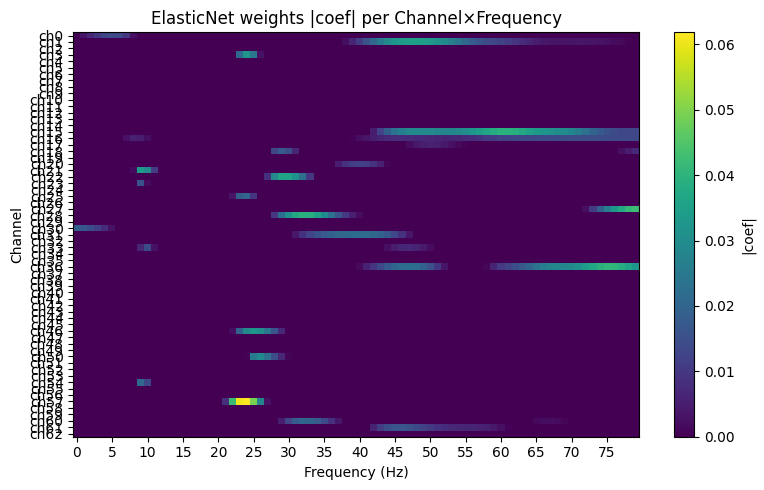

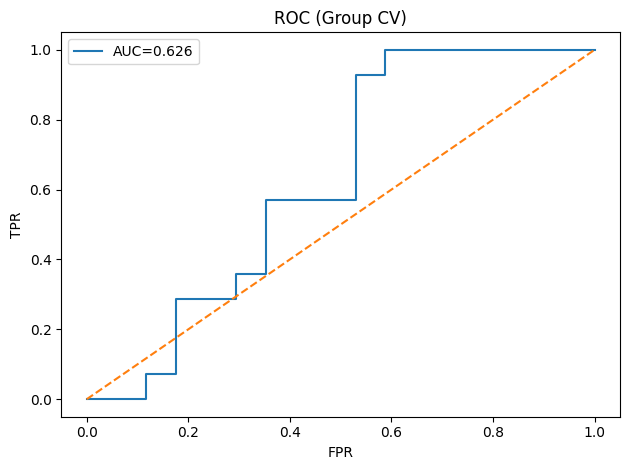

In [42]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, roc_curve, confusion_matrix
# ==== входные данные ====
mask_de = (mask_day | mask_eve)
X = Z[mask_de]
y = mask_eve[mask_de].astype(int)               # evening=1, day=0
groups = np.array([it[1] for it in results_arr])[mask_de]  # subject_id
print(f"Data: n={len(X)}, d={X.shape[1]} | day={(y==0).sum()}, evening={(y==1).sum()}, subjects={np.unique(groups).size}")

# ==== стратифицированные групповые сплиты ====
try:
    from sklearn.model_selection import StratifiedGroupKFold
    gkf = StratifiedGroupKFold(n_splits=min(5, np.unique(groups).size), shuffle=True, random_state=0)
except Exception:
    from sklearn.model_selection import GroupKFold
    gkf = GroupKFold(n_splits=min(5, np.unique(groups).size))
    print("[warn] StratifiedGroupKFold недоступен — используем GroupKFold.")

# ==== модель: ElasticNet логрег (без снижения размерности) ====
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="elasticnet", solver="saga", max_iter=40000,
        class_weight="balanced", random_state=0, n_jobs=-1
    ))
])
param_grid = {
    "clf__C": np.logspace(-3, 2, 10),
    "clf__l1_ratio": [0.2, 0.4, 0.6, 0.8]  # 0→L2, 1→L1
}

def fit_grid(scoring):
    grid = GridSearchCV(pipe, param_grid, cv=gkf, scoring=scoring, n_jobs=-1, refit=True, error_score="raise")
    grid.fit(X, y, groups=groups)
    return grid

# сначала пробуем AUC; если не получается — balanced_accuracy
try:
    grid = fit_grid("roc_auc")
    if not np.isfinite(grid.best_score_): raise ValueError("AUC nan/inf")
    score_name = "AUC"
except Exception:
    grid = fit_grid("balanced_accuracy")
    score_name = "balanced_accuracy"

print(f"Best: {grid.best_params_} | CV {score_name}={grid.best_score_:.3f}")

# === CV-предсказания для метрик/ROC ===
proba_cv = cross_val_predict(grid.best_estimator_, X, y, cv=gkf, groups=groups, method="predict_proba")[:,1]
y_pred_cv = (proba_cv >= 0.5).astype(int)
print("[GroupCV] acc=%.3f  bal-acc=%.3f  auc=%.3f" % (
    accuracy_score(y, y_pred_cv),
    balanced_accuracy_score(y, y_pred_cv),
    roc_auc_score(y, proba_cv)
))
print("Confusion matrix:\n", confusion_matrix(y, y_pred_cv))

# === финальная модель на всех данных → веса ===
est = grid.best_estimator_.fit(X, y)
w = est.named_steps["clf"].coef_.ravel()     # (d,)

# === стабильность признаков по фолдам ===
coefs = []
for tr, te in gkf.split(X, y, groups):
    est_fold = grid.best_estimator_.fit(X[tr], y[tr])
    coefs.append(est_fold.named_steps["clf"].coef_.ravel())
coefs = np.vstack(coefs)                     # (n_folds, d)
nz_rate = (np.abs(coefs) > 1e-12).mean(axis=0)      # доля фолдов с ненулевым весом
mean_abs = np.mean(np.abs(coefs), axis=0)           # средний |вес|
w_signed = w                                       # для знака на финальной модели

# === раскодируем (канал×частота) ===
psd0 = results_arr[0][0]
base_shape = psd0.shape  # (n_channels, n_freqs)
assert np.prod(base_shape) == X.shape[1]
def _pick_axis_labels(loaded, dim_len, prefer_keys, numeric_ok):
    for k in prefer_keys:
        if k in loaded and getattr(loaded[k], "ndim", 1) == 1 and len(loaded[k]) == dim_len:
            arr = np.array(loaded[k]); 
            if numeric_ok or arr.dtype.kind in ("U","S","O"): return arr
    for k in loaded.files:
        arr = np.array(loaded[k])
        if getattr(arr, "ndim", 1) == 1 and len(arr) == dim_len:
            if numeric_ok or arr.dtype.kind in ("U","S","O"): return arr
    return None

ch_names = _pick_axis_labels(loaded, base_shape[0], ("ch_names","channels","chan_names","ch"), numeric_ok=False)
freqs    = _pick_axis_labels(loaded, base_shape[1], ("freqs","frequency","f_grid","hz"), numeric_ok=True)
if ch_names is None: ch_names = np.array([f"ch{c}" for c in range(base_shape[0])], dtype=object)
if freqs is None:    freqs    = np.arange(base_shape[1], dtype=float)

W = w_signed.reshape(base_shape, order="C")
Wabs = np.abs(W)
NZ = nz_rate.reshape(base_shape, order="C")
MEANABS = mean_abs.reshape(base_shape, order="C")

# === ТОП (канал×частота) по стабильности * и * среднему |весу| ===
flat_idx = np.argsort(-NZ.ravel())[:20]
rows = []
for j in flat_idx:
    c, f = np.unravel_index(j, base_shape, order="C")
    rows.append({
        "channel": str(ch_names[c]),
        "chan_idx": int(c),
        "freq_bin": int(f),
        "freq_Hz": float(freqs[f]) if np.issubdtype(type(freqs[f]), np.number) else np.nan,
        "nz_rate": float(NZ[c, f]),
        "mean_abs_w": float(MEANABS[c, f]),
        "coef_final": float(W[c, f]),
        "sign": "evening↑" if W[c, f] > 0 else "day↑"
    })
top_cells = pd.DataFrame(rows).sort_values(["nz_rate","mean_abs_w"], ascending=False).reset_index(drop=True)
try:
    from IPython.display import display
    display(top_cells.head(12))
except Exception:
    print(top_cells.head(12).to_string(index=False))

# === агрегаты по каналам/частотам и по ПОЛОСАМ (δ/θ/α/β/γ) ===
imp_channels = pd.DataFrame({"channel": ch_names, "sum_abs_coef": Wabs.sum(axis=1), "mean_nz": NZ.mean(axis=1)})\
               .sort_values(["sum_abs_coef","mean_nz"], ascending=False).reset_index(drop=True)

imp_freqs = pd.DataFrame({"freq_bin": np.arange(base_shape[1]),
                          "freq_Hz": [float(x) if np.issubdtype(type(x), np.number) else np.nan for x in freqs],
                          "sum_abs_coef": Wabs.sum(axis=0), "mean_nz": NZ.mean(axis=0)})\
            .sort_values(["sum_abs_coef","mean_nz"], ascending=False).reset_index(drop=True)

print("\nTop channels:\n", imp_channels.head(10).to_string(index=False))
print("\nTop frequencies:\n", imp_freqs.head(10).to_string(index=False))

# Полосы (если известны реальные частоты):
def band_of(f):
    if np.isnan(f): return "bin"
    if 1<=f<4: return "delta"
    if 4<=f<8: return "theta"
    if 8<=f<13: return "alpha"
    if 13<=f<30: return "beta"
    if 30<=f<=70: return "gamma"
    return "other"

band_labels = np.array([band_of(float(fr)) for fr in freqs], dtype=object)
band_df = []
for band in ["delta","theta","alpha","beta","gamma","other"]:
    idx = np.where(band_labels == band)[0]
    if len(idx)==0: continue
    band_df.append({
        "band": band,
        "sum_abs_coef": float(Wabs[:, idx].sum()),
        "mean_nz": float(NZ[:, idx].mean())
    })
band_df = pd.DataFrame(band_df).sort_values(["sum_abs_coef","mean_nz"], ascending=False)
print("\nBands importance:\n", band_df.to_string(index=False))

# ==== графики ====
PLOT = True
if PLOT:
    # |веса| на сетке канал×частота
    plt.figure(figsize=(8,5))
    plt.imshow(Wabs, aspect="auto")
    plt.colorbar(label="|coef|")
    plt.yticks(np.arange(len(ch_names)), ch_names)
    step = max(1, len(freqs)//16); xt = np.arange(0, len(freqs), step)
    xtlbl = [f"{float(freqs[i]):.0f}" if np.isfinite(float(freqs[i])) else str(freqs[i]) for i in xt]
    plt.xticks(xt, xtlbl)
    plt.xlabel("Frequency (Hz)"); plt.ylabel("Channel")
    plt.title("ElasticNet weights |coef| per Channel×Frequency")
    plt.tight_layout(); plt.show()

    # ROC по CV
    fpr, tpr, _ = roc_curve(y, proba_cv)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y, proba_cv):.3f}")
    plt.plot([0,1],[0,1],'--'); plt.legend()
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (Group CV)")
    plt.tight_layout(); plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

def group_perm_test(estimator, X, y, groups, n_perm=5000, seed=42, metric="balanced_accuracy"):
    rng = np.random.default_rng(seed)
    try:
        cv = StratifiedGroupKFold(n_splits=min(5, np.unique(groups).size), shuffle=True, random_state=0)
    except:
        from sklearn.model_selection import GroupKFold
        cv = GroupKFold(n_splits=min(5, np.unique(groups).size))
    # наблюдаемая метрика
    from sklearn.model_selection import cross_val_predict
    proba = cross_val_predict(estimator, X, y, cv=cv, groups=groups, method="predict_proba")[:,1]
    yhat  = (proba>=0.5).astype(int)
    obs = balanced_accuracy_score(y, yhat) if metric!="auc" else roc_auc_score(y, proba)
    # пермутации меток на уровне SUBJECT (переставляем метки целых субъектов)
    uniq = np.unique(groups)
    b = 0
    for _ in range(n_perm):
        perm_map = dict(zip(uniq, rng.permutation(uniq)))  # перекидываем субъекты между классами
        y_perm = np.array([y[groups==g][0] for g in np.vectorize(perm_map.get)(groups)])
        proba_p = cross_val_predict(estimator, X, y_perm, cv=cv, groups=groups, method="predict_proba")[:,1]
        yhat_p  = (proba_p>=0.5).astype(int)
        val = balanced_accuracy_score(y_perm, yhat_p) if metric!="auc" else roc_auc_score(y_perm, proba_p)
        b += (val >= obs)
    p = (1+b)/(n_perm+1)
    return obs, p

obs_ba, p_ba = group_perm_test(grid.best_estimator_, X, y, groups, n_perm=10, metric="balanced_accuracy")
print(f"[perm] balanced-acc={obs_ba:.3f}, p={p_ba:.4f}")


In [45]:
# выкинем бины 45–55 Гц и ±5–10 Гц вокруг, подстрой под свою сетку
psd0 = results_arr[0][0]; nC, nF = psd0.shape
freqs = np.arange(nF) if "freqs" not in loaded.files else np.array(loaded["freqs"], dtype=float)
drop = (freqs>=45) & (freqs<=55)
keep_bins = np.where(~drop)[0]

# маска признаков для Z
keep_cols = np.concatenate([c*nF + keep_bins for c in range(nC)])
X_drop = X[:, keep_cols]

# та же модель/грид и GroupCV как раньше
grid2 = GridSearchCV(grid.best_estimator_, {"clf__C":[grid.best_params_["clf__C"]], "clf__l1_ratio":[grid.best_params_["clf__l1_ratio"]]},
                     cv=gkf, scoring="balanced_accuracy", n_jobs=-1, refit=True)
grid2.fit(X_drop, y, groups=groups)
proba2 = cross_val_predict(grid2.best_estimator_, X_drop, y, cv=gkf, groups=groups, method="predict_proba")[:,1]
print("[no-50Hz] bal-acc=%.3f, auc=%.3f" % (balanced_accuracy_score(y,(proba2>=0.5).astype(int)),
                                           roc_auc_score(y, proba2)))



[no-50Hz] bal-acc=0.628, auc=0.630


In [46]:
# агрегат по ch15, 62–66 Гц
ch = 15
band_mask = (freqs>=62) & (freqs<=66)
cols = np.array([ch*nF + np.where(band_mask)[0]]).ravel()
feat = X[:, cols].mean(axis=1)

import pandas as pd
df = pd.DataFrame({"feat":feat, "y":y, "subj":groups})
# если есть у каждого subj и day, и evening:
pivot = df.pivot_table(index="subj", columns="y", values="feat", aggfunc="mean")
pivot.columns = ["day","evening"]
from scipy.stats import wilcoxon
pivot = pivot.dropna()
stat,p = wilcoxon(pivot["day"], pivot["evening"])
print(f"[ch{ch}, 62–66Hz] paired Wilcoxon p={p:.4f}, n_pairs={len(pivot)}")


[ch15, 62–66Hz] paired Wilcoxon p=nan, n_pairs=0


In [47]:
import numpy as np
import pandas as pd

# ---- данные и обученная модель ----
mask_de = (mask_day | mask_eve)
X = Z[mask_de]
y = mask_eve[mask_de].astype(int)            # evening=1, day=0
est = grid.best_estimator_.fit(X, y)         # ElasticNet/LogReg из твоего грид-сёрча
scaler = est.named_steps["scaler"]
clf = est.named_steps["clf"]
w = clf.coef_.ravel()                         # (d,)

# стандартизованные признаки (как в пайплайне)
Xz = scaler.transform(X)
mu_day = Xz[y==0].mean(axis=0)
mu_eve = Xz[y==1].mean(axis=0)
delta = mu_eve - mu_day                      # (d,)

# вклад в "ночь": положительное => evening↑
contrib = w * delta                           # (d,)

# ---- раскладываем в (канал × частота) и показываем топ ----
psd0 = results_arr[0][0]
base_shape = psd0.shape                       # (n_channels, n_freqs)
assert np.prod(base_shape) == contrib.size
C, F = base_shape

# имена каналов/частот (если есть в loaded, иначе заглушки)
def _pick_axis_labels(loaded, dim_len, prefer_keys, numeric_ok):
    for k in prefer_keys:
        if k in loaded and getattr(loaded[k], "ndim", 1)==1 and len(loaded[k])==dim_len:
            arr = np.array(loaded[k]); 
            if numeric_ok or arr.dtype.kind in ("U","S","O"): return arr
    for k in loaded.files:
        arr = np.array(loaded[k])
        if getattr(arr, "ndim", 1)==1 and len(arr)==dim_len:
            if numeric_ok or arr.dtype.kind in ("U","S","O"): return arr
    return None
ch_names = _pick_axis_labels(loaded, C, ("ch_names","channels","chan_names","ch"), numeric_ok=False)
freqs    = _pick_axis_labels(loaded, F, ("freqs","frequency","f_grid","hz"), numeric_ok=True)
if ch_names is None: ch_names = np.array([f"ch{c}" for c in range(C)], dtype=object)
if freqs is None:    freqs    = np.arange(F, dtype=float)

CONTR = contrib.reshape(base_shape, order="C")

# ТОП вкладов в "ночь" (evening↑)
K = 12
flat_pos = np.argsort(-CONTR.ravel())[:K]
rows_pos = []
for j in flat_pos:
    c, f = np.unravel_index(j, base_shape, order="C")
    rows_pos.append({
        "channel": str(ch_names[c]),
        "chan_idx": int(c),
        "freq_bin": int(f),
        "freq_Hz": float(freqs[f]) if np.issubdtype(type(freqs[f]), np.number) else np.nan,
        "contrib_evening": float(CONTR[c, f])
    })
top_evening = pd.DataFrame(rows_pos)

# ТОП вкладов в "день" (самые отрицательные)
flat_neg = np.argsort(CONTR.ravel())[:K]
rows_neg = []
for j in flat_neg:
    c, f = np.unravel_index(j, base_shape, order="C")
    rows_neg.append({
        "channel": str(ch_names[c]),
        "chan_idx": int(c),
        "freq_bin": int(f),
        "freq_Hz": float(freqs[f]) if np.issubdtype(type(freqs[f]), np.number) else np.nan,
        "contrib_day": float(CONTR[c, f])
    })
top_day = pd.DataFrame(rows_neg)

# агрегаты по каналам и частотам (вклад в ночь = суммарные положительные contrib)
evening_map = np.maximum(CONTR, 0.0)
day_map     = np.maximum(-CONTR, 0.0)

imp_channels_even = pd.DataFrame({"channel": ch_names,
                                  "sum_contrib_evening": evening_map.sum(axis=1)})\
                    .sort_values("sum_contrib_evening", ascending=False).reset_index(drop=True)

imp_freqs_even = pd.DataFrame({"freq_bin": np.arange(F),
                               "freq_Hz": [float(x) if np.issubdtype(type(x), np.number) else np.nan for x in freqs],
                               "sum_contrib_evening": evening_map.sum(axis=0)})\
                 .sort_values("sum_contrib_evening", ascending=False).reset_index(drop=True)

print("Top cells (evening↑):")
try:
    from IPython.display import display
    display(top_evening)
    print("\nTop cells (day↑):")
    display(top_day)
    print("\nTop channels (evening↑):")
    display(imp_channels_even.head(10))
    print("\nTop freqs (evening↑):")
    display(imp_freqs_even.head(10))
except Exception:
    print(top_evening.to_string(index=False))
    print(top_day.to_string(index=False))
    print(imp_channels_even.head(10).to_string(index=False))
    print(imp_freqs_even.head(10).to_string(index=False))


Top cells (evening↑):


,channel,chan_idx,freq_bin,freq_Hz,contrib_evening
0,ch15,15,61,61.0,0.042954
1,ch15,15,60,60.0,0.042877
2,ch15,15,62,62.0,0.041949
3,ch15,15,59,59.0,0.041781
4,ch15,15,63,63.0,0.040087
5,ch15,15,58,58.0,0.039932
6,ch15,15,64,64.0,0.037840
7,ch57,57,24,24.0,0.037705
8,ch15,15,57,57.0,0.037671
9,ch15,15,65,65.0,0.035749



Top cells (day↑):


,channel,chan_idx,freq_bin,freq_Hz,contrib_day
0,ch0,0,32,32.0,-0.0
1,ch59,59,68,68.0,-0.0
2,ch59,59,69,69.0,-0.0
3,ch59,59,70,70.0,-0.0
4,ch59,59,71,71.0,-0.0
5,ch59,59,72,72.0,-0.0
6,ch59,59,73,73.0,-0.0
7,ch59,59,74,74.0,-0.0
8,ch59,59,75,75.0,-0.0
9,ch0,0,9,9.0,0.0



Top channels (evening↑):


,channel,sum_contrib_evening
0,ch15,1.089708
1,ch1,0.552822
2,ch36,0.520589
3,ch28,0.264593
4,ch31,0.210010
5,ch16,0.205642
6,ch61,0.169563
7,ch57,0.143840
8,ch27,0.105307
9,ch60,0.101675



Top freqs (evening↑):


,freq_bin,freq_Hz,sum_contrib_evening
0,47,47.0,0.108767
1,46,46.0,0.108641
2,48,48.0,0.105363
3,45,45.0,0.103949
4,49,49.0,0.100807
5,44,44.0,0.093250
6,50,50.0,0.092872
7,51,51.0,0.083099
8,43,43.0,0.079853
9,52,52.0,0.073806


In [48]:
# 1) собираем маску частот, исключая 45–55 Гц
psd0 = results_arr[0][0]; nC, nF = psd0.shape
freqs = np.array(loaded["freqs"]) if "freqs" in loaded.files else np.arange(nF, dtype=float)
keep_f = ~((freqs >= 45) & (freqs <= 55))

# 2) оставляем только эти столбцы в исходной матрице признаков (без снижения размерности!)
keep_cols = np.hstack([c*nF + np.where(keep_f)[0] for c in range(nC)])
X_keep = Z[mask_day | mask_eve][:, keep_cols]
y_keep = mask_eve[mask_day | mask_eve].astype(int)
groups_keep = np.array([it[1] for it in results_arr])[mask_day | mask_eve]

# 3) переобучаем твою же модель (ElasticNet) и пересчитываем вклады в ночь
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

try:
    gkf = StratifiedGroupKFold(n_splits=min(5, np.unique(groups_keep).size), shuffle=True, random_state=0)
except:
    from sklearn.model_selection import GroupKFold
    gkf = GroupKFold(n_splits=min(5, np.unique(groups_keep).size))

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="elasticnet", solver="saga",
                               class_weight="balanced", max_iter=40000, random_state=0, n_jobs=-1))
])
grid = GridSearchCV(pipe, {"clf__C":[0.1668100537200059], "clf__l1_ratio":[0.2]},  # твои best-парам
                    cv=gkf, scoring="balanced_accuracy", n_jobs=-1, refit=True)
grid.fit(X_keep, y_keep, groups=groups_keep)

# вклад в ночь
scaler = grid.best_estimator_.named_steps["scaler"]
w = grid.best_estimator_.named_steps["clf"].coef_.ravel()
Xz = scaler.transform(X_keep)
delta = Xz[y_keep==1].mean(axis=0) - Xz[y_keep==0].mean(axis=0)
contrib_keep = w * delta


In [49]:
# индексы столбцов для ch15 × 56–66 Гц
ch = 15
band = (freqs >= 56) & (freqs <= 66)
cols = ch*nF + np.where(band)[0]
feat = Z[mask_day | mask_eve][:, cols].mean(axis=1)

import pandas as pd
df = pd.DataFrame({"feat": feat,
                   "y": mask_eve[mask_day | mask_eve].astype(int),
                   "subj": np.array([it[1] for it in results_arr])[mask_day | mask_eve]})
pivot = df.pivot_table(index="subj", columns="y", values="feat", aggfunc="mean").dropna()
pivot.columns = ["day","evening"]

from scipy.stats import wilcoxon
stat, p = wilcoxon(pivot["day"], pivot["evening"])
print(f"[ch15, 56–66 Hz] paired Wilcoxon p={p:.4f}, n_pairs={len(pivot)}")


[ch15, 56–66 Hz] paired Wilcoxon p=nan, n_pairs=0


In [50]:
import numpy as np, pandas as pd

mask_de = (mask_day | mask_eve)
y = mask_eve[mask_de].astype(int)  # evening=1, day=0
subj = np.array([it[1] for it in results_arr])[mask_de]  # subject_id в том же порядке, что Z

tab = pd.crosstab(pd.Series(subj, name="subject"),
                  pd.Series(y, name="cond"))  # столбцы 0=day,1=evening
print(tab.head(20))
print("subjects with BOTH conds:", ( (tab>0).sum(axis=1)==2 ).sum())


cond     0  1
subject      
1        0  2
2        0  2
3        2  0
4        2  0
5        0  2
6        2  0
7        2  0
8        0  2
9        2  0
10       0  2
11       2  0
12       2  0
13       0  2
14       1  0
15       2  0
16       0  2
subjects with BOTH conds: 0


In [52]:
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
import statsmodels.api as sm

# форма PSD
psd0 = results_arr[0][0]
nC, nF = psd0.shape
freqs = np.array(loaded["freqs"]) if "freqs" in loaded.files else np.arange(nF, dtype=float)

# индексы колонок для ch=15 и 56–66 Гц
ch = 15
fmin, fmax = 56.0, 66.0
band_mask = (freqs >= fmin) & (freqs <= fmax)
cols = ch*nF + np.where(band_mask)[0]

X = Z[mask_de]              # без снижения размерности
feat = X[:, cols].mean(axis=1)   # средняя мощность в этом канале×диапазоне

y = mask_eve[mask_de].astype(int)                   # 1=evening, 0=day
subj = np.array([it[1] for it in results_arr])[mask_de]  # subject_id

# агрегируем на уровне субъекта (чтобы убрать зависимость повторов)
df = pd.DataFrame({"feat": feat, "cond": y, "subj": subj})
subj_avg = df.groupby(["subj","cond"], as_index=False)["feat"].mean()

# непарный тест (между субъектами)
feat_day = subj_avg.loc[subj_avg["cond"]==0, "feat"].values
feat_eve = subj_avg.loc[subj_avg["cond"]==1, "feat"].values
if len(feat_day) > 0 and len(feat_eve) > 0:
    stat, p_mw = mannwhitneyu(feat_day, feat_eve, alternative="two-sided")
    print(f"[ch{ch}, {fmin:.0f}–{fmax:.0f} Hz] Mann–Whitney p={p_mw:.4f}  (n_day={len(feat_day)}, n_eve={len(feat_eve)})")
else:
    print("В одном из классов нет субъектов → непарный тест невозможен.")

# регрессия с кластер-робастными SE по субъектам: feat ~ cond
Xreg = sm.add_constant(subj_avg["cond"].values)  # 1=evening
yreg = subj_avg["feat"].values
model = sm.OLS(yreg, Xreg).fit(cov_type="cluster", cov_kwds={"groups": subj_avg["subj"].values})
print(model.summary().as_text())
# Коэффициент при cond — разница evening−day (в средних по субъекту), робастно по кластерам


[ch15, 56–66 Hz] Mann–Whitney p=0.0079  (n_day=9, n_eve=7)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     9.879
Date:                Fri, 05 Sep 2025   Prob (F-statistic):            0.00670
Time:                        15:32:24   Log-Likelihood:                -18.373
No. Observations:                  16   AIC:                             40.75
Df Residuals:                      14   BIC:                             42.29
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [53]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ===== 0) данные и вспомогательные =====
mask_de = (mask_day | mask_eve)
X = Z[mask_de]                                   # (n_samples, n_features)
y = mask_eve[mask_de].astype(int)                # 1=evening, 0=day
subj = np.array([it[1] for it in results_arr])[mask_de]  # subject_id в том же порядке

# форма PSD одного примера (до векторизации): (n_channels, n_freqs)
psd0 = results_arr[0][0]
nC, nF = psd0.shape
# сетка частот (если нет в .npz — возьмём индексы как Гц)
if "freqs" in loaded.files:
    freqs = np.array(loaded["freqs"], dtype=float)
else:
    freqs = np.arange(nF, dtype=float)

def cols_for(ch, fmin, fmax):
    """Столбцы Z, соответствующие (канал=ch, fmin..fmax включительно)."""
    band = (freqs >= float(fmin)) & (freqs <= float(fmax))
    idx_f = np.where(band)[0]
    if len(idx_f) == 0:
        return np.array([], dtype=int)
    return ch*nF + idx_f

def subject_level_vectors(feat_vec, y, subj):
    """Агрегация до среднего по субъекту -> два массива (day, evening)."""
    df = pd.DataFrame({"feat": feat_vec, "cond": y, "subj": subj})
    subj_avg = df.groupby(["subj","cond"], as_index=False)["feat"].mean()
    feat_day = subj_avg.loc[subj_avg["cond"]==0, "feat"].values
    feat_eve = subj_avg.loc[subj_avg["cond"]==1, "feat"].values
    return feat_day, feat_eve, subj_avg

def mw_with_effect(x, y):
    """Mann–Whitney two-sided + rank-biserial (Cliff’s delta)."""
    if len(x)==0 or len(y)==0:
        return np.nan, np.nan
    U, p = mannwhitneyu(x, y, alternative="two-sided")
    r_rb = 1 - 2*U/(len(x)*len(y))
    return float(p), float(r_rb)

# ===== 1) набор тестов =====
tests = []

# ch15: 57–66 Гц — несколько узких окон (3 Гц с шагом 3) + целый диапазон
for (fmin, fmax) in [(57,60), (60,63), (63,66), (57,66)]:
    tests.append({"label": f"ch15 {fmin}-{fmax}Hz", "ch":15, "fmin":fmin, "fmax":fmax})

# ch36: 74–77 Гц
tests.append({"label":"ch36 74-77Hz", "ch":36, "fmin":74, "fmax":77})

# ch57: 23–24 Гц
tests.append({"label":"ch57 23-24Hz", "ch":57, "fmin":23, "fmax":24})

# ===== 2) прогон тестов (between-subjects) =====
rows = []
for t in tests:
    cols = cols_for(t["ch"], t["fmin"], t["fmax"])
    if cols.size == 0:
        rows.append({**t, "n_day":0, "n_eve":0, "mean_day":np.nan, "mean_eve":np.nan,
                     "diff_eve_minus_day":np.nan, "p":np.nan, "r_rb":np.nan})
        continue

    feat = X[:, cols].mean(axis=1)  # агрегируем окно до одного числа на наблюдение
    x_day, x_eve, subj_avg = subject_level_vectors(feat, y, subj)
    if len(x_day)==0 or len(x_eve)==0:
        rows.append({**t, "n_day":len(x_day), "n_eve":len(x_eve), "mean_day":np.nan, "mean_eve":np.nan,
                     "diff_eve_minus_day":np.nan, "p":np.nan, "r_rb":np.nan})
        continue

    p, r_rb = mw_with_effect(x_day, x_eve)
    rows.append({
        **t,
        "n_day": int(len(x_day)),
        "n_eve": int(len(x_eve)),
        "mean_day": float(np.mean(x_day)),
        "mean_eve": float(np.mean(x_eve)),
        "diff_eve_minus_day": float(np.mean(x_eve) - np.mean(x_day)),
        "p": p,
        "r_rb": r_rb
    })

res = pd.DataFrame(rows)

# ===== 3) FDR (Benjamini–Hochberg) по всему набору тестов =====
mask_valid = res["p"].notna()
if mask_valid.any():
    res.loc[mask_valid, "p_fdr"] = multipletests(res.loc[mask_valid, "p"].values, method="fdr_bh")[1]
else:
    res["p_fdr"] = np.nan

# красиво отсортируем: сначала по p_fdr, потом по |эффекту|
res_sorted = res.sort_values(["p_fdr","p","r_rb"], ascending=[True, True, False]).reset_index(drop=True)

# вывод
try:
    from IPython.display import display
    display(res_sorted)
except Exception:
    print(res_sorted.to_string(index=False))


,label,ch,fmin,fmax,n_day,n_eve,mean_day,mean_eve,diff_eve_minus_day,p,r_rb,p_fdr
0,ch15 57-60Hz,15,57,60,9,7,0.567462,-0.596402,-1.163864,0.007867,-0.777778,0.011801
1,ch15 60-63Hz,15,60,63,9,7,0.566347,-0.593254,-1.159601,0.007867,-0.777778,0.011801
2,ch15 63-66Hz,15,63,66,9,7,0.559041,-0.583380,-1.142421,0.007867,-0.777778,0.011801
3,ch15 57-66Hz,15,57,66,9,7,0.563959,-0.590665,-1.154624,0.007867,-0.777778,0.011801
4,ch57 23-24Hz,57,23,24,9,7,-0.288812,0.329073,0.617885,0.114161,0.492063,0.136993
5,ch36 74-77Hz,36,74,77,9,7,0.251065,-0.385456,-0.636521,0.469755,-0.238095,0.469755


channel  diff_evening_minus_day
   ch15               -1.154624
   ch61               -0.844689
    ch1               -0.823647
   ch20               -0.813160
    ch8               -0.793080
   ch39               -0.792040
   ch17               -0.773820
   ch44               -0.773134
   ch49               -0.771537
   ch28               -0.761002
[fallback] Недостаточно распознанных стандартных каналов для топомапы → рисую bar-plot.


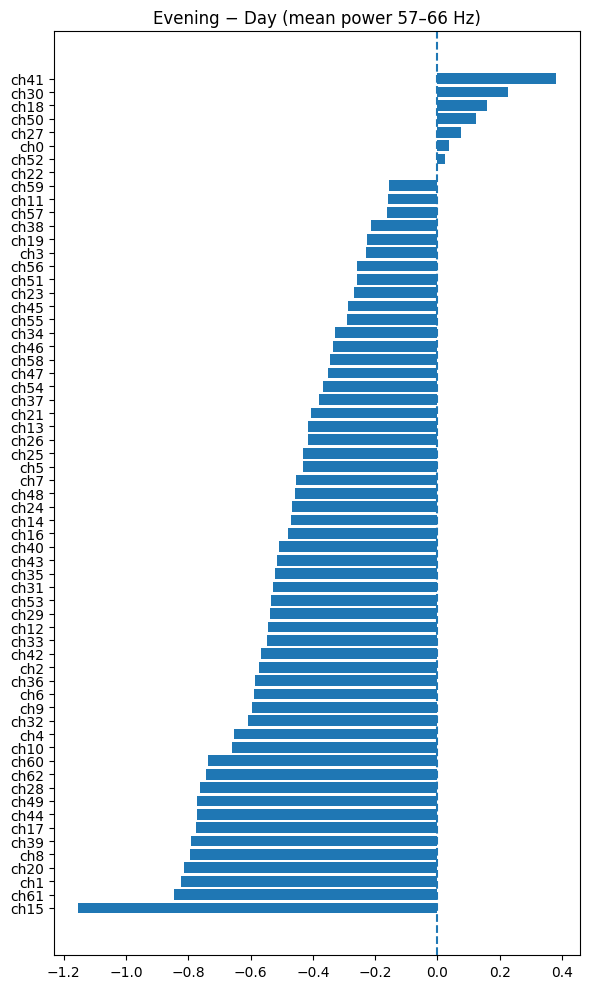

Saved: topomap_57_66Hz.png


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 0) входные данные ===
mask_de = (mask_day | mask_eve)
X_full = Z[mask_de]                                 # (n_samples, n_features)
y       = mask_eve[mask_de].astype(int)            # 1=evening, 0=day
subj    = np.array([it[1] for it in results_arr])[mask_de]  # subject_id, тот же порядок

psd0 = results_arr[0][0]
nC, nF = psd0.shape

# частотная сетка
freqs = np.array(loaded["freqs"], dtype=float) if "freqs" in loaded.files else np.arange(nF, dtype=float)

# имена каналов (если в .npz нет — будут ch0..)
def _pick_axis_labels(loaded, dim_len, prefer_keys, numeric_ok):
    for k in prefer_keys:
        if k in loaded and getattr(loaded[k], "ndim", 1)==1 and len(loaded[k])==dim_len:
            arr = np.array(loaded[k])
            if numeric_ok or arr.dtype.kind in ("U","S","O"):
                return arr
    for k in loaded.files:
        arr = np.array(loaded[k])
        if getattr(arr, "ndim", 1)==1 and len(arr)==dim_len:
            if numeric_ok or arr.dtype.kind in ("U","S","O"):
                return arr
    return None

ch_names = _pick_axis_labels(loaded, nC, ("ch_names","channels","chan_names","ch"), numeric_ok=False)
if ch_names is None:
    ch_names = np.array([f"ch{c}" for c in range(nC)], dtype=object)

# === 1) собираем признак: средняя мощность в 57–66 Гц на КАЖДОМ канале ===
fmin, fmax = 57.0, 66.0
band_mask = (freqs >= fmin) & (freqs <= fmax)
idx_f = np.where(band_mask)[0]
if idx_f.size == 0:
    raise RuntimeError("В сетке частот нет бинoв в 57–66 Гц. Проверь 'freqs'.")

X_chan = np.empty((X_full.shape[0], nC), float)
for c in range(nC):
    cols = c*nF + idx_f
    X_chan[:, c] = X_full[:, cols].mean(axis=1)

# === 2) усредняем на уровне субъекта → diff = mean_evening − mean_day по каждому каналу ===
df = pd.DataFrame(X_chan, columns=[str(n) for n in ch_names])
df["cond"] = y
df["subj"] = subj
subj_avg = df.groupby(["subj", "cond"], as_index=False).mean(numeric_only=True)

mean_day = subj_avg.loc[subj_avg["cond"]==0, ch_names.astype(str).tolist()].mean(axis=0)
mean_eve = subj_avg.loc[subj_avg["cond"]==1, ch_names.astype(str).tolist()].mean(axis=0)
diff = (mean_eve - mean_day).astype(float).values  # длины nC

# выведем топ-10 каналов по |разнице|
abs_order = np.argsort(-np.abs(diff))
top_table = pd.DataFrame({
    "channel": ch_names[abs_order].astype(str),
    "diff_evening_minus_day": diff[abs_order]
})
print(top_table.head(10).to_string(index=False))

# === 3) топография через MNE (если доступен и имена стандартные); иначе — барчарт ===
title = f"Evening − Day (mean power {int(fmin)}–{int(fmax)} Hz)"
out_png = "topomap_57_66Hz.png"

def plot_bar(ch_names, diff, title, outpath):
    order = np.argsort(diff)
    plt.figure(figsize=(6, 10))
    plt.barh(np.array(ch_names)[order].astype(str), diff[order])
    plt.axvline(0, ls="--")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()

try:
    import mne
    info = mne.create_info(ch_names=[str(x) for x in ch_names], sfreq=1000., ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")
    # возьмём те каналы, у которых есть координаты
    picks = [i for i, ch in enumerate(info["chs"]) if np.linalg.norm(ch["loc"][:3]) > 0]
    if len(picks) >= 10:
        pos = np.array([info["chs"][i]["loc"][:2] for i in picks], float)
        data = diff[picks]
        vmax = np.max(np.abs(data)) if np.isfinite(np.max(np.abs(data))) else None
        plt.figure(figsize=(6,5))
        mne.viz.plot_topomap(data, pos, outlines="head",
                             cmap="RdBu_r",
                             vmin=-vmax if vmax is not None else None,
                             vmax= vmax,
                             sensors=True, contours=6)
        plt.title(title)
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_png}")
    else:
        print("[fallback] Недостаточно распознанных стандартных каналов для топомапы → рисую bar-plot.")
        plot_bar(ch_names, diff, title, out_png)
        print(f"Saved: {out_png}")
except Exception as e:
    print(f"[fallback] MNE недоступен или ошибка топомапы: {e}\nРисую bar-plot.")
    plot_bar(ch_names, diff, title, out_png)
    print(f"Saved: {out_png}")
